In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns

import re
import os
import sys

import pickle
import warnings
warnings.filterwarnings('ignore')

In [2]:
from models.mix_model import load_data
base_dir = "/home/mhi/Data/dataset"
considered_date = datetime(2015,1,1)
latest_date = datetime(2025,10,1)
test_date = datetime(2023,3,1)
ac_model = 'CRJ700'

df_rep, df_util_diff = load_data(base_dir, 10, latest_date, ac_model)
df_rep_train = df_rep[df_rep['REMOVAL_DATE'] < test_date]


#### Read data: New model (CALE)

In [3]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import roc_auc_score, f1_score, precision_recall_fscore_support, roc_curve, precision_recall_curve

## Compute AUC-ROC / peak-F1 score based on the threshold --> How to choose threshold...
peak_adj_columns = ['AUC', 'F1', 'TH', 'pr', 're']
def peakf1_acc(label, score):
    # grader = metricor()
    result = pd.DataFrame(columns=peak_adj_columns)
    if np.sum(label) != 0:
        auc = roc_auc_score(label, score)

        # plor ROC curve
        fpr, tpr, _ = roc_curve(label, score)
        pr, re, thresholds = precision_recall_curve(label, score)
        
        peak_f1, peak_ind = np.nanmax(2*(pr*re)/(pr+re)), np.nanargmax(2*(pr*re)/(pr+re))
        peak_ths = thresholds[peak_ind] 
        
        #range anomaly 
        preds = score > peak_ths

        result.loc[0] = [auc, peak_f1, peak_ths, pr[peak_ind], re[peak_ind]]
        # result.loc[0] = [auc, pr[peak_ind], re[peak_ind], peak_f1, peak_ths, Rprecision, Rrecall, Rf, precision_at_k, f1_adj, pr_adj, re_adj, auc_adj]
        return result


def result_f1_acc(methods, scores, labels):
    result_org = pd.DataFrame(columns=['method'] + peak_adj_columns)
    j = 0
    for i, method in enumerate(methods):
        # r_tmp = get_acc(label.reshape(-1)[:len(scores[i])], np.array(scores[i]), slidingWindow, ths)
        # print('LEN SCORES:', len(scores[i]), len(labels[i]))
        if len(scores[i]) < len(labels[i]):
            label_rev = labels[i][len(labels[i])-len(scores[i]):].copy()
        else:
            label_rev = labels[i]
        # print('LEN SCORES:', len(scores[i]), len(label), len(label_rev))
        r_tmp = peakf1_acc(label_rev.reshape(-1)[:len(scores[i])], np.array(scores[i]))
        if r_tmp is not None:
            result_org.loc[j] = [method] + list(r_tmp.loc[0])
        else:
            result_org.loc[j] = [method] + [0]*len(peak_adj_columns)
        j+=1


    # display(result_org)
    return result_org


def draw_distribution(df, dfs, names, att_names, subtitles):
    palette = {
        'U': 'tab:orange',
        'Non-U': 'tab:blue'
    }
    # plt.figure(figsize=(8,5))
    fig, ax = plt.subplots(1, 4, figsize=(25, 4))

    ## Histogram of flight hours
    df_fh = df[['REMOVAL_TYPE_CODE', 'FLIGHT_HOURS_tcn']].dropna()
    df_fh = df_fh[df_fh['FLIGHT_HOURS_tcn'] < 5000]
    df_fh['group'] = df_fh['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')
    sns.histplot(data=df_fh, x='FLIGHT_HOURS_tcn', hue='group', bins=50, stat='density', common_norm=False, alpha=0.5,palette=palette, ax=ax[0])
    # ax[0].legend_.remove()
    ax[0].set_xlabel('Flight Hours')
    ax[0].set_title('(a) Flight Hours')

    for i, (df, att_name, name, subtitle) in enumerate(zip(dfs, att_names, names, subtitles)):
        print(i, att_name)
        df_plot = df[['REMOVAL_TYPE_CODE', att_name]].dropna()
        df_plot['group'] = df_plot['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')
        # scaler = StandardScaler()
        scaler = MinMaxScaler()
        df_plot[att_name] = scaler.fit_transform(df_plot[[att_name]])

        sns.histplot(data=df_plot, x=att_name, hue='group', bins=50, stat='density', common_norm=False, alpha=0.5,palette=palette, ax=ax[i+1])
        # ax[i+1].legend_.remove()
        ax[i+1].set_xlabel('p')
        ax[i+1].set_ylabel('')
        ax[i+1].set_title(f'{subtitle} p: {name}')

    handles, labels = ax[0].get_legend_handles_labels()
    legend = ax[0].legend_
    handles = legend.legend_handles
    labels = [t.get_text() for t in legend.get_texts()]
    print(labels)

    for aa in ax:
        if aa.legend_ is not None:
            aa.legend_.remove()

    # handles = handles[1:]
    # labels = labels[1:]

    fig.legend(
        handles,
        labels=['Unscheduled (U)', 'Scheduled (S)'],
        ncols=2,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        fontsize=25,
        frameon=False, 
        title=None
    )

    plt.tight_layout()
    plt.savefig('./png/compare_prob.png', bbox_inches='tight')
    plt.show()

def revise_prediction(df, ata, df_rep_train, pred='mu_f', exclude='all'):
    df_rep_ata = df_rep_train[df_rep_train['ATA_NUMBER'] == ata]
    df_rep_sch = df_rep_ata[df_rep_ata['REMOVAL_TYPE_CODE'] != 'U']

    df_op_comp = pd.DataFrame(columns=['op', 'ata', 'avg'])
    ops = df['OPERATOR_CODE'].unique()
    idx = 0
    df_rev = df.copy()
    df_rev[pred] = df_rev[pred].clip(lower=100)

    org_l = len(df_rev)
    print('ORG:', len(df_rev))

    if exclude == 'all' or exclude == 'S':
        for op in ops:
            df_tr_op = df_rep_sch[df_rep_sch['OPERATOR_CODE'] == op]
            # print(op, np.mean(df_tr_op['FLIGHT_HOURS']))
            m = np.mean(df_tr_op['FLIGHT_HOURS'])
            df_op_comp.loc[idx] = [op, ata, m]
            df_rev = df_rev[
                ~(
                    (df_rev["OPERATOR_CODE"] == op) &
                    (df_rev['REMOVAL_TYPE_CODE'] == 'U') &  
                    (df_rev['FLIGHT_HOURS_tcn'] > df_rev[pred] + m) 
                )
            ]
            idx +=1
        print('UNSCH:', len(df_rev))
    
    rem_un = org_l - len(df_rev)

    if exclude == 'all' or exclude == 'U':
        df_rev = df_rev[
            ~( 
                (df['REMOVAL_TYPE_CODE'] != 'U') & 
                (df['FLIGHT_HOURS_tcn'] < df[pred])
            )
        ]
        print('SCH:', len(df_rev))
    rem_sc = org_l - rem_un - len(df_rev)

    
    df_u = df_rev[df_rev['REMOVAL_TYPE_CODE']=='U'].copy()
    # mdae_all = np.median(abs(df_rev['FLIGHT_HOURS_tcn'] - df_rev[pred]))
    # mdape_all = np.median(abs(df_rev['FLIGHT_HOURS_tcn'] - df_rev[pred])/df_rev['FLIGHT_HOURS_tcn'])
    mdae = np.median(abs(df_u['FLIGHT_HOURS_tcn'] - df_u[pred]))
    mdape = np.median(abs(df_u['FLIGHT_HOURS_tcn'] - df_u[pred])/df_u['FLIGHT_HOURS_tcn'])

    return df_rev, mdae, mdape, rem_un, rem_sc

    

#### Draw distribution of p 

243203 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243203_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
364.24253657839904 190.72671205925116
409.1565367820408 172.0632625782183
433.02237591455423 174.31600884222365
0 logit_f
1 u_pred
2 u_pred
['U', 'Non-U']


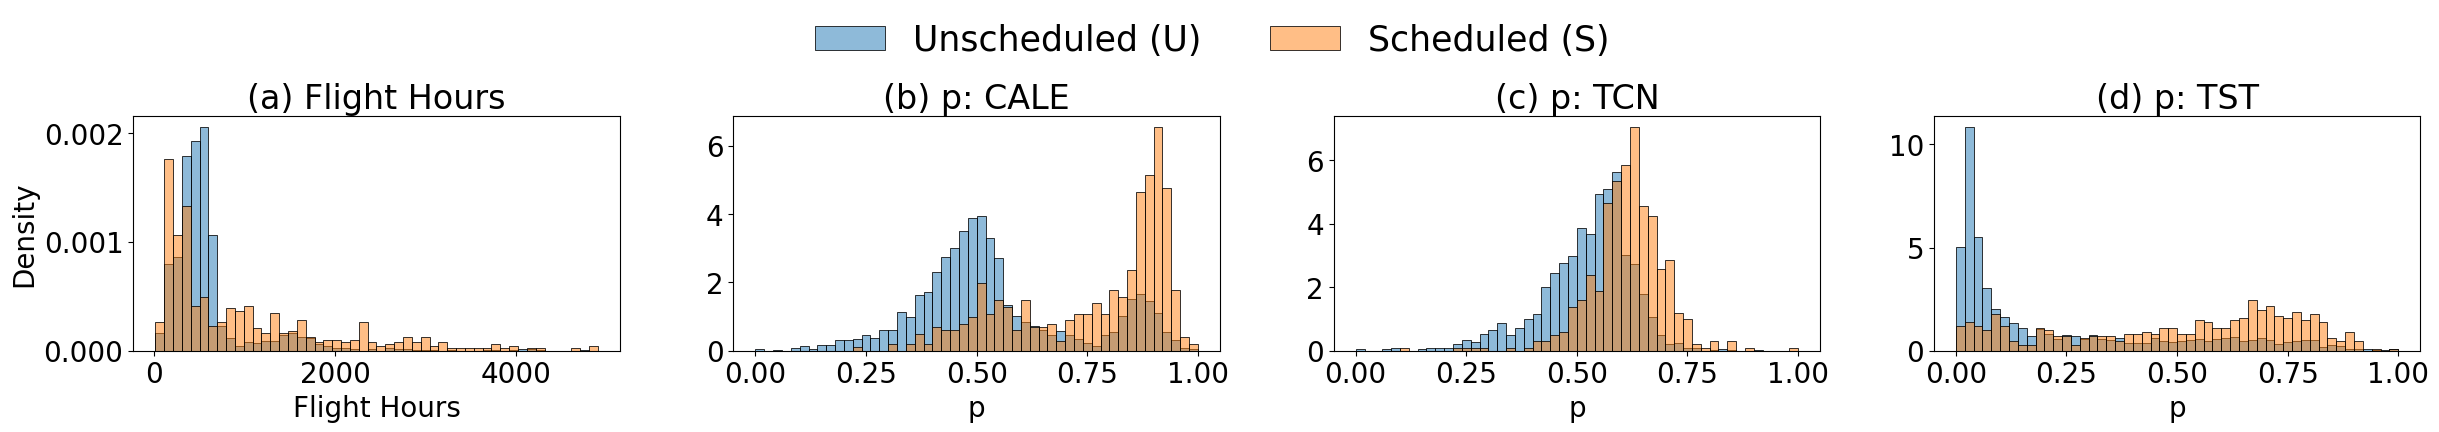

In [12]:
plt.rcParams.update({'font.size': 20})

sel_ata = 243203
# sel_ata = 324301
dir1 = '/home/parkj182/research/MHI-2025/mhi/test_result_up/'
filelist= os.listdir(dir1)
files = [f for f in filelist if f.startswith('UP_TCN_ops_EDV')]
# print(files)

names = ['CALE', 'TCN', 'TST']
att_names = ['logit_f', 'u_pred', 'u_pred']
subtitles= ['(b)', '(c)', '(d)']
dfs = []
palette = {
    'U': 'tab:orange',
    'Non-U': 'tab:blue'
}
key_cols = [
    "PART_SN",
    "AC_SN",
    "INSTALL_DATE",
    "REMOVAL_DATE",
    "OPERATOR_CODE",
    "FLIGHT_HOURS_tcn",
]

## CALE
for f in files:
    match = re.search(r'_ata_(\d+)', f)
    if match:
        ata_num = int(match.group(1))
        if ata_num == sel_ata:
            print(ata_num, f)
            df_up_ata = pd.read_csv(dir1+f, index_col=None)
            break

df_up_au = df_up_ata[df_up_ata['REMOVAL_TYPE_CODE'] == 'U'].copy()
err_up = abs(df_up_au['mu_f']-df_up_au['FLIGHT_HOURS_tcn'])
print(np.median(err_up), np.median(abs(df_up_ata['mu_f']-df_up_ata['FLIGHT_HOURS_tcn'])))

dfs.append(df_up_ata)

dir2 = '/home/parkj182/research/MHI-2025/mhi/test_result_logit/'
filelist2= os.listdir(dir2)
# print(filelist2)
# files = [f for f in filelist if f.startswith('UP_')]
file_tcns = [f for f in filelist2 if 'TCN_AttenMulti' in f]
file_tsts = [f for f in filelist2 if 'TSTMulti' in f]

for f in file_tcns:
    match = re.search(r'_ata_(\d+)', f)
    if match:
        ata_num = int(match.group(1))
        if ata_num == sel_ata:
            # print(ata_num)
            df_tcn_ata = pd.read_csv(dir2+f, index_col=None)
            df_tcn_ata_f = df_tcn_ata.merge(
                df_up_ata[key_cols].drop_duplicates(),
                on=key_cols,
                how='inner'
            )
            break
for f in file_tsts:
    match = re.search(r'_ata_(\d+)', f)
    if match:
        ata_num = int(match.group(1))
        if ata_num == sel_ata:
            # print(ata_num)
            df_tst_ata = pd.read_csv(dir2+f, index_col=None)
            df_tst_ata_f = df_tst_ata.merge(
                df_up_ata[key_cols].drop_duplicates(),
                on=key_cols,
                how='inner'
            )
            break

df_tcn_au = df_tcn_ata[df_tcn_ata['REMOVAL_TYPE_CODE'] == 'U'].copy()
df_tst_au = df_tst_ata[df_tst_ata['REMOVAL_TYPE_CODE'] == 'U'].copy()
dfs.append(df_tcn_ata_f)
dfs.append(df_tst_ata_f)

err_tst = abs(df_tst_au['FH_MH_TST']-df_tst_au['FLIGHT_HOURS_tcn'])
try:
    err_tcn = abs(df_tcn_au['FH_MH_CNN']-df_tcn_au['FLIGHT_HOURS_tcn'])
    print(np.median(err_tcn), np.median(abs(df_tcn_ata['FH_MH_CNN']-df_tcn_ata['FLIGHT_HOURS_tcn'])))
except:
    err_tcn = abs(df_tcn_au['FH_MH_TCN']-df_tcn_au['FLIGHT_HOURS_tcn'])
    print(np.median(err_tcn), np.median(abs(df_tcn_ata['FH_MH_TCN']-df_tcn_ata['FLIGHT_HOURS_tcn'])))



print(np.median(err_tst), np.median(abs(df_tst_ata['FH_MH_TST']-df_tst_ata['FLIGHT_HOURS_tcn'])))


draw_distribution(df_up_ata, dfs, names, att_names, subtitles)


In [ ]:
# chk_df = dfs[0]
# chk_sch = chk_df[chk_df['REMOVAL_TYPE_CODE'] !='U']
# chk_sch[['FLIGHT_HOURS_tcn', 'mu_f', 'logit_f', 'REMOVAL_TYPE_CODE']]

# chk_sch[chk_sch['FLIGHT_HOURS_tcn'] < chk_sch['mu_f']][['FLIGHT_HOURS_tcn', 'mu_f', 'sigma_f','logit_f', 'REMOVAL_TYPE_CODE']]

### Comparison of classification results

In [125]:
# sel_ata = 243201
# target_atas_all= [243201, 324301, 344401, 215206, 243203, 253203, 313301, 324101, 324201, 324101, 335141, 722110]
target_atas_all= [243201, 324301,  243203, 313301, 344401, 324201]
ata_names = ['Main \nBattery', 'Break \nAssembly', 'APU \nBattery', 'Quick \nAccess \nRecorder', 'Radio \nTransceiver', 'Nose \nWheel &\nTire \nAssembly']
# target_atas_all = np.sort(target_atas_all)

dir1 = '/home/parkj182/research/MHI-2025/mhi/test_result_up/'
filelist= os.listdir(dir1)
files = [f for f in filelist if f.startswith('UP_TCN_ops_EDV')]
dir2 = '/home/parkj182/research/MHI-2025/mhi/test_result_logit/'
filelist2= os.listdir(dir2)
file_tcns = [f for f in filelist2 if 'TCN_AttenMulti' in f]
file_tsts = [f for f in filelist2 if 'TSTMulti' in f]

df_acc_all = pd.DataFrame(columns= ['ata', 'name', 'method', 'rem_un', 'rem_sc'] + peak_adj_columns)
for ata, ata_name in zip(target_atas_all, ata_names):
    methods, scores, labels, mdae, mdape, rem_uns, rem_scs, nums = [], [], [], [], [], [], [], []
    for f in files:
        match = re.search(r'_ata_(\d+)', f)
        if match:
            ata_num = int(match.group(1))
            if ata_num == ata:
                print(ata_num, f)
                df_up_ata = pd.read_csv(dir1+f, index_col=None)
                df_up_ata_rev, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata, ata, df_rep_train, pred='mu_f', exclude='all')
                methods.append('CALE')
                # scaler = MinMaxScaler()
                # scores.append(scaler.fit_transform(df_up_ata_rev['logit_f'].to_numpy().reshape(-1,1)))
                scores.append(df_up_ata_rev['logit_f'].to_numpy())
                labels.append(df_up_ata_rev['REMOVAL_TYPE_CODE'].apply(lambda x: 1 if x == 'U' else 0).to_numpy())
                mdae.append(md)
                mdape.append(mdp)
                # mdae_all.append(md_all)
                # mdape_all.append(mdp_all)
                rem_uns.append(rem_un)
                rem_scs.append(rem_sc)
                nums.append(len(df_up_ata_rev))
                break    

    for f in file_tcns:
        match = re.search(r'_ata_(\d+)', f)
        if match:
            ata_num = int(match.group(1))
            if ata_num == ata:
                print(ata_num, f)
                df_tcn_ata = pd.read_csv(dir2+f, index_col=None)
                if 'FH_MH_CNN' in df_tcn_ata.columns:
                    df_tcn_ata['FH_MH_TCN'] = df_tcn_ata['FH_MH_CNN']
                df_tcn_ata_f = df_tcn_ata.merge(
                    df_up_ata[key_cols].drop_duplicates(),
                    on=key_cols,
                    how='inner'
                )
                df_tcn_ata_rev, md, mdp, rem_un, rem_sc = revise_prediction(df_tcn_ata_f, ata, df_rep_train, pred='FH_MH_TCN')
                methods.append('TCN')
                # scaler = MinMaxScaler()
                # scores.append(scaler.fit_transform(df_tcn_ata_rev['u_pred'].to_numpy().reshape(-1,1)))
                scores.append(df_tcn_ata_f['u_pred'].to_numpy())
                labels.append(df_tcn_ata_f['REMOVAL_TYPE_CODE'].apply(lambda x: 1 if x == 'U' else 0).to_numpy())
                mdae.append(md)
                mdape.append(mdp)
                # mdae_all.append(md_all)
                # mdape_all.append(mdp_all)
                rem_uns.append(rem_un)
                rem_scs.append(rem_sc)
                nums.append(len(df_tcn_ata_rev))
                break
    for f in file_tsts:
        match = re.search(r'_ata_(\d+)', f)
        if match:
            ata_num = int(match.group(1))
            if ata_num == ata:
                print(ata_num, f)
                df_tst_ata = pd.read_csv(dir2+f, index_col=None)
                df_tst_ata_f = df_tst_ata.merge(
                    df_up_ata[key_cols].drop_duplicates(),
                    on=key_cols,
                    how='inner'
                )
                df_tst_ata_rev, md, mdp, rem_un, rem_sc = revise_prediction(df_tst_ata_f, ata, df_rep_train, pred='FH_MH_TST')
                methods.append('TST')
                # scaler = MinMaxScaler()
                # scores.append(scaler.fit_transform(df_tst_ata_rev['u_pred'].to_numpy().reshape(-1,1)))
                scores.append(df_tst_ata_f['u_pred'].to_numpy())
                labels.append(df_tst_ata_f['REMOVAL_TYPE_CODE'].apply(lambda x: 1 if x == 'U' else 0).to_numpy())
                mdae.append(md)
                mdape.append(mdp)
                # mdae_all.append(md_all)
                # mdape_all.append(mdp_all)
                rem_uns.append(rem_un)
                rem_scs.append(rem_sc)
                nums.append(len(df_tst_ata_rev))
                break
    
    df_t = result_f1_acc(methods, scores, labels)
    df_t['ata'] = ata
    df_t['name'] = ata_name
    df_t['mdae'] = mdae
    df_t['mdape'] = mdape
    # df_t['mdae_all'] = mdae_all
    # df_t['mdape_all'] = mdape_all
    df_t['rem_un'] = rem_uns
    df_t['rem_sc'] = rem_scs
    df_t['nums'] = nums
    df_t['num'] = [len(df_up_ata_rev)/len(df_up_ata)*100, len(df_tcn_ata_rev)/len(df_tcn_ata_f)*100, len(df_tst_ata_rev)/len(df_tst_ata_f)*100]
    df_t['num_org'] = [len(df_up_ata_rev), len(df_tcn_ata_rev), len(df_tst_ata_rev)]
    df_acc_all = pd.concat([df_acc_all, df_t])


243201 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 1533
UNSCH: 1499
SCH: 1251
243201 ata4_Multi_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243201_CONFIG_2_model_TCN_AttenMulti_seqata_3_seqsn_3_b_16.csv
ORG: 1533
UNSCH: 1501
SCH: 860
243201 ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243201_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv
ORG: 1533
UNSCH: 1502
SCH: 990
324301 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324301_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 4464
UNSCH: 4438
SCH: 3878
324301 ata4_Multi_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324301_CONFIG_2_model_TCN_AttenMulti_seqata_3_seqsn_3_b_16.csv
ORG: 4464
UNSCH: 4440
SCH: 1648
324301 ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324301_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv
ORG: 4464
UNSCH: 4440
SCH: 1394
243203 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243203_CONFIG_2_model_TCNAtten_seqata_3

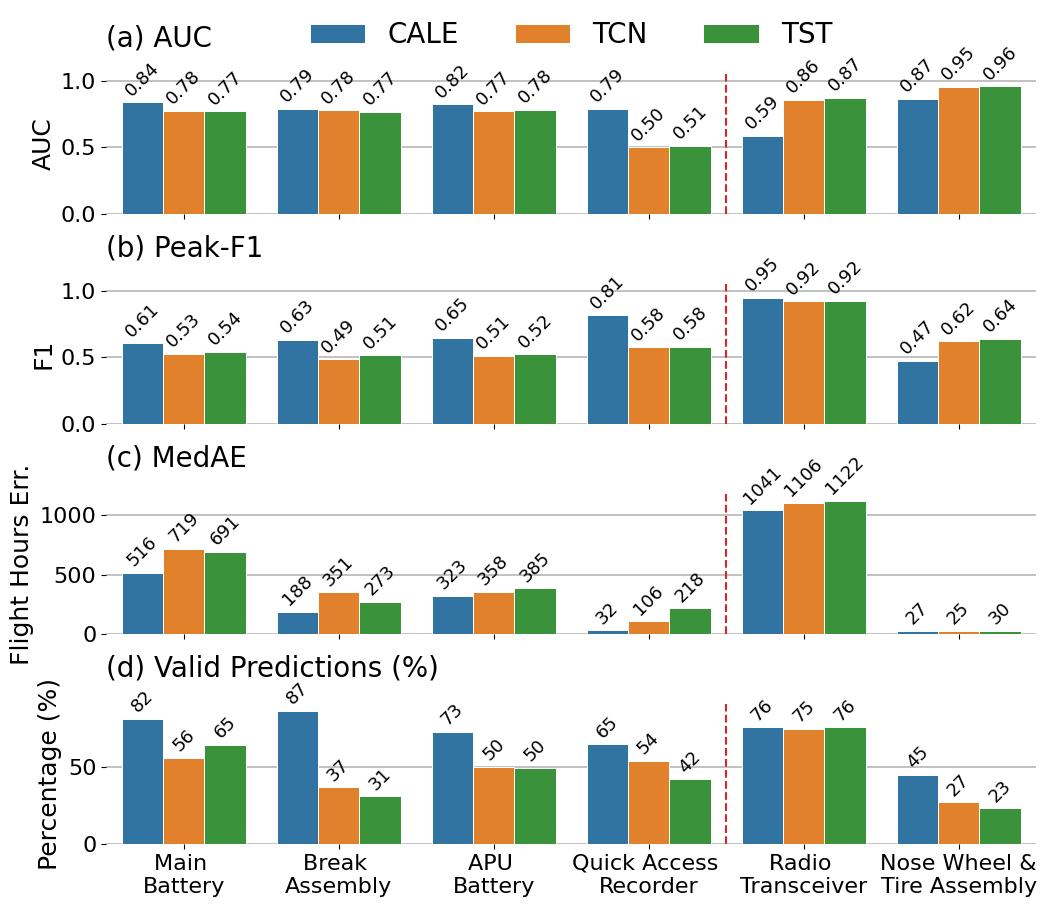

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

ata_names = ['Main \nBattery', 'Break \nAssembly', 'APU \nBattery', 'Quick Access \nRecorder', 'Radio \nTransceiver', 'Nose Wheel &\nTire Assembly']
# plt.style.use("ggplot")
plt.style.use("default")
sns.reset_defaults()
# sns.set_theme(style="whitegrid", context="notebook")
palette = sns.color_palette("tab10", n_colors=df_acc_all["method"].nunique())

plt.rcParams.update({'font.size': 20})
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
# ata_order = list(df_acc_all["ata"].unique())
# ata_order_gap = ata_order[:4] + [" "] + ata_order[4:]

fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 10),
    sharex=True,
    gridspec_kw={"hspace": 0.5}
)
# fig.patch.set_facecolor("white")

for idx, (ax, metric, title) in enumerate(zip(
    axes,
    ["AUC", "F1", "mdae", "num"],
    ["(a) AUC", "(b) Peak-F1", "(c) MedAE", "(d) Valid Predictions (%)"]
)):
    # ax.set_facecolor("#F0F0F0")

    ax.set_axisbelow(True)
    sns.barplot(
        data=df_acc_all,
        x="name",
        y=metric,
        hue="method",
        # order=ata_order_gap,
        palette=palette,
        edgecolor="white",
        linewidth=0.7,
        ax=ax
    )

    ax.axvline(
        x=3.5,
        color="tab:red",
        linestyle="--",
        linewidth=1.5,
        alpha=1
    )

    ax.set_title(title, fontsize=20, loc="left", pad=20)
    
    
    ax.set_xlabel("")
    if idx <2:
        ax.set_ylabel(metric, fontsize=18)
        ax.set_ylim(0, 1.05)
    elif idx ==2:
        ax.set_ylabel('Flight Hours Err.', fontsize=18)
    else:
        ax.set_ylabel("Percentage (%)", fontsize=18)

    ax.grid(True, axis="y", linewidth=1.1)
    ax.grid(False, axis="x")

    for spine in ax.spines.values():
        spine.set_visible(False)

    # 막대 위 숫자 표시
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.2f" if idx <2 else "%.0f",
            fontsize=13,
            padding=2,
            # color="0.25",
            rotation=45
        )

axes[0].legend(
    title=None,
    loc="lower center",
    bbox_to_anchor=(0.5, 1),
    ncols=3,
    frameon=False,
    fontsize=20
)

axes[1].legend_.remove()
axes[2].legend_.remove()
axes[3].legend_.remove()
axes[3].set_xticklabels(ata_names, rotation=0, ha="center", fontsize=16)

plt.tight_layout()
plt.savefig('./png/cls_acc.png', bbox_inches="tight")
plt.show()

### For Table 

In [124]:
df_acc_all['mdape_p'] = df_acc_all['mdape']*100
df_acc_all[['ata', 'name', 'method', 'mdae', 'mdape', 'nums']].round(2)

,ata,name,method,mdae,mdape,nums
0,243201,Main \nBattery,CALE,616.18,0.56,1285.0
1,243201,Main \nBattery,TCN,718.97,0.53,860.0
2,243201,Main \nBattery,TST,690.66,0.51,990.0
0,324301,Break \nAssembly,CALE,198.06,0.37,3904.0
1,324301,Break \nAssembly,TCN,351.08,0.74,1648.0
2,324301,Break \nAssembly,TST,273.45,0.54,1394.0
0,243203,APU \nBattery,CALE,364.24,0.52,1872.0
1,243203,APU \nBattery,TCN,358.34,0.58,1264.0
2,243203,APU \nBattery,TST,384.52,0.60,1251.0
0,313301,Quick \nAccess \nRecorder,CALE,32.62,0.21,202.0


In [132]:
# sel_ata = 243201
# target_atas_all= [243201, 324301, 344401, 215206, 243203, 253203, 313301, 324101, 324201, 324101, 335141, 722110]
target_atas_all= [243201, 324301,  243203, 313301, 344401, 324201]
ata_names = ['Main \nBattery', 'Break \nAssembly', 'APU \nBattery', 'Quick \nAccess \nRecorder', 'Radio \nTransceiver', 'Nose \nWheel &\nTire \nAssembly']
# target_atas_all = np.sort(target_atas_all)

dir1 = '/home/parkj182/research/MHI-2025/mhi/test_result_up/'
filelist= os.listdir(dir1)
files = [f for f in filelist if f.startswith('UP_TCN_ops_EDV')]

df_acc_all_enc = pd.DataFrame(columns= ['ata', 'name', 'method'] )
for ata, ata_name in zip(target_atas_all, ata_names):
    methods, mdae, mdape, nums = [], [], [], []
    for f in files:
        match = re.search(r'_ata_(\d+)', f)
        if match:
            ata_num = int(match.group(1))
            if ata_num == ata:
                print(ata_num, f)
                df_up_ata2 = pd.read_csv(dir1+f, index_col=None)
                df_up_ata_rev2, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata2, ata, df_rep_train, pred='mu_f')
                methods.append('CALE')
                mdae.append(md)
                mdape.append(mdp)
                nums.append(len(df_up_ata_rev2))

                df_up_ata_rev2, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata2, ata, df_rep_train, pred='y_ac', exclude='S')
                methods.append('EncL')
                mdae.append(md)
                mdape.append(mdp)
                nums.append(len(df_up_ata_rev2))
# 
                df_up_ata_rev2, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata2, ata, df_rep_train, pred='y_pn')
                methods.append('EncG')
                mdae.append(md)
                mdape.append(mdp)
                nums.append(len(df_up_ata_rev2))
                print(nums)
                break    

    
    # df_t = result_f1_acc(methods, scores, labels)
    df_t = pd.DataFrame()
    df_t['method'] =methods
    df_t['ata'] = ata
    df_t['name'] = ata_name
    df_t['mdae'] = mdae
    df_t['mdape'] = mdape
    df_t['nums'] = nums

    # df_t['mdae_all'] = mdae_all
    # df_t['mdape_all'] = mdape_all
    df_acc_all_enc = pd.concat([df_acc_all_enc, df_t])


243201 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 1533
UNSCH: 1499
SCH: 1251
ORG: 1533
UNSCH: 1501
ORG: 1533
UNSCH: 1527
SCH: 322
[1251, 1501, 322]
324301 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324301_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 4464
UNSCH: 4438
SCH: 3878
ORG: 4464
UNSCH: 4439
ORG: 4464
UNSCH: 4449
SCH: 509
[3878, 4439, 509]
243203 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243203_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 2510
UNSCH: 2471
SCH: 1833
ORG: 2510
UNSCH: 2471
ORG: 2510
UNSCH: 2499
SCH: 529
[1833, 2471, 529]
313301 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_313301_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 308
UNSCH: 306
SCH: 200
ORG: 308
UNSCH: 306
ORG: 308
UNSCH: 307
SCH: 129
[200, 306, 129]
344401 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_344401_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 754
UNSCH: 659
SCH: 573
ORG: 754

In [133]:
df_acc_all_enc['mdape_p'] = df_acc_all_enc['mdape']*100
df_acc_all_enc[['ata', 'name', 'method', 'mdae', 'mdape', 'nums']].round(2)

,ata,name,method,mdae,mdape,nums
0,243201,Main \nBattery,CALE,515.60,0.51,1251.0
1,243201,Main \nBattery,EncL,691.78,0.53,1501.0
2,243201,Main \nBattery,EncG,2931.76,2.88,322.0
0,324301,Break \nAssembly,CALE,188.21,0.35,3878.0
1,324301,Break \nAssembly,EncL,320.61,0.66,4439.0
2,324301,Break \nAssembly,EncG,3970.36,8.18,509.0
0,243203,APU \nBattery,CALE,323.48,0.47,1833.0
1,243203,APU \nBattery,EncL,362.41,0.57,2471.0
2,243203,APU \nBattery,EncG,1790.18,3.35,529.0
0,313301,Quick \nAccess \nRecorder,CALE,32.05,0.21,200.0


### DeepAR for table

In [94]:
def get_type(dfs, df_rep):
    # selected_operators = ['EDV', 'CLH','HXA', 'IBX', 'ANE', 'JZA', 'SKW', 'PSY']
    keys = ['AC_SN', 'PART_NO', 'INSTALL_DATE', 'REMOVAL_DATE']
    print(ata)
    df_rev_ar2 = pd.DataFrame()
    df_rep_ata_t = df_rep[df_rep['ATA_NUMBER'] == ata].copy()
    df_rep_ata_t['INSTALL_DATE']= pd.to_datetime(df_rep_ata_t['INSTALL_DATE']).dt.normalize()
    df_rep_ata_t['REMOVAL_DATE']= pd.to_datetime(df_rep_ata_t['REMOVAL_DATE']).dt.normalize()
    df_rep_ata_t['PART_NO'] =df_rep_ata_t['PART_NO'].astype(str)

    for yp in dfs:
        # df_rep_op_t = df_rep_ata_t[df_rep_ata_t['OPERATOR_CODE'] == op].copy()
        yp['FH_AR2'] = yp['FH_AR2'].clip(lower=100)
        yp['INSTALL_DATE']= pd.to_datetime(yp['INSTALL_DATE']).dt.normalize()
        yp['REMOVAL_DATE']= pd.to_datetime(yp['REMOVAL_DATE']).dt.normalize()
        yp['PART_NO'] = yp['PART_NO'].astype(str)
        yp2 = yp.merge(df_rep_ata_t[keys + ['REMOVAL_TYPE_CODE', 'OPERATOR_CODE', 'ATA_NUMBER']], on=keys, how='left')
        yp2['abs_err'] = abs(yp2['FLIGHT_HOURS'] - yp2['FH_AR2'])
        df_rev_ar2 = pd.concat([df_rev_ar2, yp2])
    
    
    df_rev_ar = df_rev_ar2[df_rev_ar2['REMOVAL_TYPE_CODE'] == 'U']
    return df_rev_ar

# sel_ata = 243201
# target_atas_all= [243201, 324301, 344401, 215206, 243203, 253203, 313301, 324101, 324201, 324101, 335141, 722110]
target_atas_all= [243201, 324301,  243203, 313301, 344401, 324201]
ata_names = ['Main \nBattery', 'Break \nAssembly', 'APU \nBattery', 'Quick \nAccess \nRecorder', 'Radio \nTransceiver', 'Nose \nWheel &\nTire \nAssembly']
# target_atas_all = np.sort(target_atas_all)

dir1 = '/home/parkj182/research/MHI-2025/mhi/data_ata4/'
filelist= os.listdir(dir1)
files = [f for f in filelist if f.startswith('deepar2')]
# files = [f for f in files if f.startswith('len_3.csv')]

df_acc_all_ar = pd.DataFrame(columns= ['ata', 'name', 'method'] )
for ata, ata_name in zip(target_atas_all, ata_names):
    methods, mdae, mdape = [], [], []
    files_ata = [f for f in files if ata == int(f.split('_')[5])]
    print(ata, files_ata)
    dfs = [pd.read_csv(dir1+f, index_col=None) for f in files_ata]
    df_ar_rev = get_type(dfs, df_rep)
    df_ar_rev['abs_err'] = abs(df_ar_rev['FLIGHT_HOURS']- df_ar_rev['FH_AR2'])
    methods.append('DeepAR')
    
    df_t = pd.DataFrame()
    df_t['method'] =methods
    df_t['ata'] = ata
    df_t['name'] = ata_name
    df_t['mdae'] = np.median(df_ar_rev['abs_err'])
    df_t['mdape'] = np.median(df_ar_rev['abs_err']/df_ar_rev['FLIGHT_HOURS'])
    df_t['nums'] = len(df_ar_rev)
    df_acc_all_ar = pd.concat([df_acc_all_ar, df_t])

df_acc_all_ar


243201 ['deepar2_icde_test_ata_EDV_243201_len_3.csv', 'deepar2_icde_test_ata_CLH_243201_len_3.csv', 'deepar2_icde_test_ata_HXA_243201_len_3.csv', 'deepar2_icde_test_ata_IBX_243201_len_3.csv', 'deepar2_icde_test_ata_ANE_243201_len_3.csv', 'deepar2_icde_test_ata_JZA_243201_len_3.csv', 'deepar2_icde_test_ata_SKW_243201_len_3.csv', 'deepar2_icde_test_ata_PSY_243201_len_3.csv']
243201
324301 ['deepar2_icde_test_ata_EDV_324301_len_3.csv', 'deepar2_icde_test_ata_CLH_324301_len_3.csv', 'deepar2_icde_test_ata_HXA_324301_len_3.csv', 'deepar2_icde_test_ata_IBX_324301_len_3.csv', 'deepar2_icde_test_ata_ANE_324301_len_3.csv', 'deepar2_icde_test_ata_JZA_324301_len_3.csv', 'deepar2_icde_test_ata_SKW_324301_len_3.csv', 'deepar2_icde_test_ata_PSY_324301_len_3.csv']
324301
243203 ['deepar2_icde_test_ata_EDV_243203_len_3.csv', 'deepar2_icde_test_ata_CLH_243203_len_3.csv', 'deepar2_icde_test_ata_HXA_243203_len_3.csv', 'deepar2_icde_test_ata_IBX_243203_len_3.csv', 'deepar2_icde_test_ata_ANE_243203_len_3.cs

,ata,name,method,mdae,mdape,nums
0,243201,Main \nBattery,DeepAR,682.807430,0.713196,238.0
0,324301,Break \nAssembly,DeepAR,174.311335,0.387389,410.0
0,243203,APU \nBattery,DeepAR,281.808900,0.538057,443.0
0,313301,Quick \nAccess \nRecorder,DeepAR,30.860830,0.189832,123.0
0,344401,Radio \nTransceiver,DeepAR,816.514395,0.899028,432.0
0,324201,Nose \nWheel &\nTire \nAssembly,DeepAR,26.880000,0.177877,466.0


In [95]:
df_acc_all_enc['mdape_p'] = df_acc_all_enc['mdape']*100
df_acc_all_enc[['ata', 'name', 'method', 'mdae', 'mdape', 'nums']].round(2)

,ata,name,method,mdae,mdape,nums
0,243201,Main \nBattery,CALE,515.60,0.51,1251.0
1,243201,Main \nBattery,EncL,691.78,0.53,908.0
2,243201,Main \nBattery,EncG,2931.76,2.88,322.0
0,324301,Break \nAssembly,CALE,188.21,0.35,3878.0
1,324301,Break \nAssembly,EncL,320.61,0.66,1621.0
2,324301,Break \nAssembly,EncG,3970.36,8.18,509.0
0,243203,APU \nBattery,CALE,323.48,0.47,1833.0
1,243203,APU \nBattery,EncL,362.41,0.57,1327.0
2,243203,APU \nBattery,EncG,1790.18,3.35,529.0
0,313301,Quick \nAccess \nRecorder,CALE,32.05,0.21,200.0


In [98]:
df_acc_all['mdape_p'] = df_acc_all['mdape']*100
df_acc_all[['ata', 'name', 'method', 'mdae', 'mdape', 'nums']].round(2)

,ata,name,method,mdae,mdape,nums
0,243201,Main \nBattery,CALE,515.60,0.51,1251.0
1,243201,Main \nBattery,TCN,718.97,0.53,860.0
2,243201,Main \nBattery,TST,690.66,0.51,990.0
0,324301,Break \nAssembly,CALE,188.21,0.35,3878.0
1,324301,Break \nAssembly,TCN,351.08,0.74,1648.0
2,324301,Break \nAssembly,TST,273.45,0.54,1394.0
0,243203,APU \nBattery,CALE,323.48,0.47,1833.0
1,243203,APU \nBattery,TCN,358.34,0.58,1264.0
2,243203,APU \nBattery,TST,384.52,0.60,1251.0
0,313301,Quick \nAccess \nRecorder,CALE,32.05,0.21,200.0


### Table: percentage included

In [104]:
df_chk_nums = pd.concat([df_acc_all_ar[['ata', 'method', 'name', 'nums']], df_acc_all[['ata', 'method', 'name','nums']]])
ratio_df = (
    df_chk_nums[df_chk_nums["method"].isin(["DeepAR", "CALE"])]
    .pivot_table(index=["ata", "name"], columns="method", values="nums", aggfunc="first")
    .reset_index()
)

ratio_df["deepar_over_cale"] = ratio_df["DeepAR"] / ratio_df["CALE"]
ratio_df

method,ata,name,CALE,DeepAR,deepar_over_cale
0,243201,Main \nBattery,1251.0,238.0,0.190248
1,243203,APU \nBattery,1833.0,443.0,0.241680
2,313301,Quick \nAccess \nRecorder,200.0,123.0,0.615000
3,324201,Nose \nWheel &\nTire \nAssembly,4829.0,466.0,0.096500
4,324301,Break \nAssembly,3878.0,410.0,0.105725
5,344401,Radio \nTransceiver,573.0,432.0,0.753927


### Not figure, but number to add

In [134]:
df_radio = df_rep_train[df_rep_train['ATA_NUMBER']==344401]
df_un_cnt = df_radio.groupby('REMOVAL_TYPE_CODE').count()['PART_NO']

print('U-percent',(df_un_cnt.loc['U'])/sum(df_un_cnt)*100)

counts_by_sn = df_radio.groupby('PART_SN')['PART_NO'].count()

print('SN<3 percent', (counts_by_sn <= 3).mean() * 100)

# plt.figure(figsize=(8, 4))
# plt.hist(counts_by_sn.to_list(), bins=100)
# plt.xlabel('PART_NO count per PART_SN')
# plt.ylabel('Number of PART_SN')
# plt.title('Distribution of PART_NO counts by PART_SN')
# plt.tight_layout()
# plt.show()



U-percent 88.83824072933349
SN<3 percent 69.0902447935696


In [135]:
df_radio = df_rep_train[df_rep_train['ATA_NUMBER']==324201]
df_un_cnt = df_radio.groupby('REMOVAL_TYPE_CODE').count()['PART_NO']

print('U-percent',(df_un_cnt.loc['U'])/sum(df_un_cnt)*100)


counts_by_sn = df_radio.groupby('PART_SN')['PART_NO'].count()
print('SN<3 percent', (counts_by_sn >= 3).mean() * 100)

# plt.figure(figsize=(8, 4))
# plt.hist(counts_by_sn.to_list(), bins=100)
# plt.xlabel('PART_NO count per PART_SN')
# plt.ylabel('Number of PART_SN')
# plt.title('Distribution of PART_NO counts by PART_SN')
# plt.tight_layout()
# plt.show()

np.mean(df_radio['FLIGHT_HOURS']), np.std(df_radio['FLIGHT_HOURS'])

U-percent 3.305958903309463
SN<3 percent 85.34923339011925


(324.433498942794, 1151.2669055493363)

### Accuracy comparison to add numbers

In [170]:
df_acc_all

,ata,name,method,rem_un,rem_sc,AUC,F1,TH,pr,re,mdae,mdape,nums,num,num_org,mdape_p
0,243201,Main \nBattery,CALE,34,248,0.839222,0.606586,0.836981,0.552050,0.673077,515.601125,0.506976,1251.0,81.604697,1251.0,50.697635
1,243201,Main \nBattery,TCN,32,641,0.775126,0.527950,-1.150876,0.485714,0.578231,718.972827,0.525060,860.0,56.099152,860.0,52.505952
2,243201,Main \nBattery,TST,31,512,0.771057,0.540382,-2.081270,0.475452,0.625850,690.659062,0.510183,990.0,64.579256,990.0,51.018349
0,324301,Break \nAssembly,CALE,26,560,0.790193,0.634093,1.557649,0.609603,0.660633,188.214661,0.352048,3878.0,86.872760,3878.0,35.204844
1,324301,Break \nAssembly,TCN,24,2792,0.778413,0.486535,-0.375047,0.419505,0.579060,351.084618,0.738380,1648.0,36.917563,1648.0,73.838018
2,324301,Break \nAssembly,TST,24,3046,0.767114,0.514385,1.519417,0.434462,0.630342,273.446894,0.536847,1394.0,31.227599,1394.0,53.684725
0,243203,APU \nBattery,CALE,39,638,0.824711,0.648165,-0.065957,0.556068,0.776824,323.483729,0.466893,1833.0,73.027888,1833.0,46.689331
1,243203,APU \nBattery,TCN,34,1212,0.771720,0.510851,-1.302844,0.441558,0.605941,358.342135,0.577582,1264.0,50.358566,1264.0,57.758213
2,243203,APU \nBattery,TST,34,1225,0.781275,0.524565,-2.412596,0.424205,0.687129,384.516519,0.598166,1251.0,49.840637,1251.0,59.816589
0,313301,Quick \nAccess \nRecorder,CALE,2,106,0.789512,0.814545,0.102468,0.732026,0.918033,32.052639,0.205623,200.0,64.935065,200.0,20.562317


In [172]:
baselines = ["TCN", "TST"]

def improvement(cale, base, metric):
    if metric in ["mdae", "mdape"]:
        return (base - cale) / base * 100
    else:  # F1, AUC 등 높을수록 좋은 metric
        return (cale - base) / base * 100


rows = []

for base_method in baselines:
    # ----- overall: 모든 ATA 평균 기준 -----
    cale_all = df_acc_all[df_acc_all["method"] == "CALE"]
    base_all = df_acc_all[df_acc_all["method"] == base_method]

    overall = (
        cale_all[["ata", "mdae", "F1"]]
        .merge(
            base_all[["ata", "mdae", "F1"]],
            on="ata",
            suffixes=("_CALE", f"_{base_method}")
        )
    )

    overall_mdae_imp = improvement(
        overall["mdae_CALE"].mean(),
        overall[f"mdae_{base_method}"].mean(),
        "mdae"
    )

    overall_f1_imp = improvement(
        overall["F1_CALE"].mean(),
        overall[f"F1_{base_method}"].mean(),
        "F1"
    )

    rows.append({
        "scope": "overall",
        "compare": f"CALE vs {base_method}",
        "metric": "mdae",
        "improvement_pct": overall_mdae_imp,
    })

    rows.append({
        "scope": "overall",
        "compare": f"CALE vs {base_method}",
        "metric": "F1",
        "improvement_pct": overall_f1_imp,
    })

    # ----- up_to: ATA별 성능향상 중 최대 -----
    overall["mdae_improvement_pct"] = (
        (overall[f"mdae_{base_method}"] - overall["mdae_CALE"])
        / overall[f"mdae_{base_method}"] * 100
    )

    overall["F1_improvement_pct"] = (
        (overall["F1_CALE"] - overall[f"F1_{base_method}"])
        / overall[f"F1_{base_method}"] * 100
    )

    best_mdae = overall.loc[overall["mdae_improvement_pct"].idxmax()]
    best_f1 = overall.loc[overall["F1_improvement_pct"].idxmax()]

    rows.append({
        "scope": "up_to",
        "compare": f"CALE vs {base_method}",
        "metric": "mdae",
        "ata": best_mdae["ata"],
        "improvement_pct": best_mdae["mdae_improvement_pct"],
    })

    rows.append({
        "scope": "up_to",
        "compare": f"CALE vs {base_method}",
        "metric": "F1",
        "ata": best_f1["ata"],
        "improvement_pct": best_f1["F1_improvement_pct"],
    })

df_improve = pd.DataFrame(rows)
df_improve

,scope,compare,metric,improvement_pct,ata
0,overall,CALE vs TCN,mdae,20.208129,NaN
1,overall,CALE vs TCN,F1,13.258160,NaN
2,up_to,CALE vs TCN,mdae,69.778340,313301.0
3,up_to,CALE vs TCN,F1,41.560117,313301.0
4,overall,CALE vs TST,mdae,21.752280,NaN
5,overall,CALE vs TST,F1,10.831531,NaN
6,up_to,CALE vs TST,mdae,85.272294,313301.0
7,up_to,CALE vs TST,F1,40.724316,313301.0


In [168]:
# metric_col = "num_org"
metric_col='mdae'

df_num = df_acc_all.copy()
df_num[metric_col] = pd.to_numeric(df_num[metric_col])

# ata별 method를 column으로 펼치기
df_num_wide = df_num.pivot_table(
    index=["ata", "name"],
    columns="method",
    values=metric_col,
    aggfunc="sum"
).reset_index()

# ata별 percentage
df_num_wide["CALE_vs_TCN_pct"] = df_num_wide["CALE"] / df_num_wide["TCN"] * 100
df_num_wide["CALE_vs_TST_pct"] = df_num_wide["CALE"] / df_num_wide["TST"] * 100

df_num_wide

method,ata,name,CALE,TCN,TST,CALE_vs_TCN_pct,CALE_vs_TST_pct
0,243201,Main \nBattery,515.601125,718.972827,690.659062,71.713576,74.653495
1,243203,APU \nBattery,323.483729,358.342135,384.516519,90.272312,84.127394
2,313301,Quick \nAccess \nRecorder,32.052639,106.058498,217.634965,30.221660,14.727706
3,324201,Nose \nWheel &\nTire \nAssembly,26.639069,25.399591,29.599914,104.879913,89.997117
4,324301,Break \nAssembly,188.214661,351.084618,273.446894,53.609487,68.830426
5,344401,Radio \nTransceiver,1040.946173,1105.748946,1122.352712,94.139468,92.746795


In [169]:
overall = df_num.groupby("method")[metric_col].sum()

overall_pct = pd.DataFrame({
    "comparison": ["CALE / TCN", "CALE / TST"],
    "percentage": [
        overall["CALE"] / overall["TCN"] * 100,
        overall["CALE"] / overall["TST"] * 100,
    ]
})

overall_pct

,comparison,percentage
0,CALE / TCN,79.791871
1,CALE / TST,78.247720


### For boxplot, ablation study

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import os

target_atas_all = [243201, 324301, 243203, 313301, 344401, 324201]
ata_names = [
    'Main \nBattery',
    'Break \nAssembly',
    'APU \nBattery',
    'Quick Access \nRecorder',
    'Radio \nTransceiver',
    'Nose Wheel &\nTire Assembly'
]

dir1 = '/home/parkj182/research/MHI-2025/mhi/test_result_up/'
filelist = os.listdir(dir1)
files = [f for f in filelist if f.startswith('UP_TCN_ops_EDV')]

box_dfs = []

for ata, ata_name in zip(target_atas_all, ata_names):
    for f in files:
        match = re.search(r'_ata_(\d+)', f)
        if match and int(match.group(1)) == ata:
            print(ata, f)

            df_up_ata = pd.read_csv(dir1 + f, index_col=None)

            df_up_ata_rev, md, mdp,  rem_un, rem_sc = revise_prediction(
                df_up_ata,
                ata,
                df_rep_train,
                pred='mu_f'
            )

            df_u = df_up_ata_rev[
                df_up_ata_rev["REMOVAL_TYPE_CODE"] == "U"
            ].copy()

            df_u["ata"] = ata
            df_u["name"] = ata_name

            box_dfs.append(df_u)
            break

df_box = pd.concat(box_dfs, ignore_index=True)

243201 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 1533
UNSCH: 1499
SCH: 1251
324301 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324301_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 4464
UNSCH: 4438
SCH: 3878
243203 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243203_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 2510
UNSCH: 2471
SCH: 1833
313301 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_313301_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 308
UNSCH: 306
SCH: 200
344401 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_344401_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 754
UNSCH: 659
SCH: 573
324201 UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 10692
UNSCH: 10689
SCH: 4829


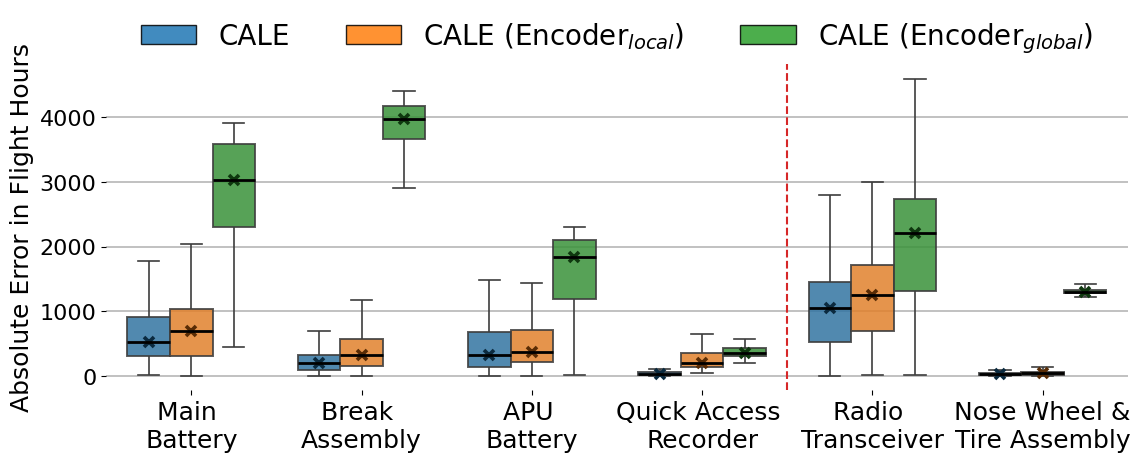

In [57]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns

value_cols = ["mu_f", "y_ac", "y_pn"]
err_cols = [f"{col}_abs_err" for col in value_cols]

att_name_map = {
    "mu_f_abs_err": r"CALE",
    "y_ac_abs_err": r"CALE (Encoder$_{local}$)",
    "y_pn_abs_err": r"CALE (Encoder$_{global}$)",
}
att_names = list(att_name_map.values())

df_box_err = df_box.copy()

# prediction 값이 0보다 작으면 100으로 setting
df_box_err[value_cols] = df_box_err[value_cols].mask(
    df_box_err[value_cols] < 0,
    100
)

# FLIGHT_HOURS_tcn과의 absolute error 계산
for col in value_cols:
    df_box_err[f"{col}_abs_err"] = (
        df_box_err[col] - df_box_err["FLIGHT_HOURS_tcn"]
    ).abs()

df_box_long = df_box_err.melt(
    id_vars=["ata", "name"],
    value_vars=err_cols,
    var_name="variable",
    value_name="value"
)

df_box_long["att_name"] = df_box_long["variable"].map(att_name_map)

plt.style.use("default")
sns.reset_defaults()

palette = sns.color_palette("tab10", n_colors=len(att_names))

def darken_color(color, amount=0.65):
    rgb = mcolors.to_rgb(color)
    return tuple((1 - amount) * c for c in rgb)

palette2 = [darken_color(c, amount=0.65) for c in palette]

plt.rcParams.update({"font.size": 20})
plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16

fig, ax = plt.subplots(figsize=(12, 5))

sns.boxplot(
    data=df_box_long,
    x="name",
    y="value",
    hue="att_name",
    hue_order=att_names,
    order=ata_names,
    palette=palette,
    showfliers=False,
    linewidth=1.4,
    width=0.75,
    medianprops={"color": "black", "linewidth": 2.0},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2},
    legend=False,
    ax=ax
)

for patch in ax.patches:
    patch.set_alpha(0.85)

sns.pointplot(
    data=df_box_long,
    x="name",
    y="value",
    hue="att_name",
    hue_order=att_names,
    order=ata_names,
    estimator="median",
    errorbar=None,
    dodge=0.5,
    markers="x",
    linestyles="",
    palette=palette2,
    scale=1.3,
    legend=False,
    ax=ax
)

ax.axvline(
    x=3.5,
    color="tab:red",
    linestyle="--",
    linewidth=1.5,
    alpha=1
)

ax.set_xlabel("")
ax.set_ylabel("Absolute Error in Flight Hours", fontsize=18)

ax.grid(True, axis="y", linewidth=1.1)
ax.grid(False, axis="x")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_handles = [
    Patch(
        facecolor=palette[i],
        edgecolor="black",
        label=att_names[i],
        alpha=0.85
    )
    for i in range(len(att_names))
]

ax.legend(
    handles=legend_handles,
    title=None,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.95),
    ncols=3,
    frameon=False,
    fontsize=20
)

ax.set_xticklabels(ata_names, rotation=0, ha="center", fontsize=18)

plt.tight_layout()
plt.savefig("./png/abbr_box.png", bbox_inches="tight")
plt.show()

In [54]:
baseline_cols = {
    "y_ac_abs_err": r"CALE (Enc$_{L}$ only)",
    "y_pn_abs_err": r"CALE (Enc$_{G}$ only)",
}

improvement_rows = []
for baseline_col, baseline_name in baseline_cols.items():
    baseline_overall = df_box_err[baseline_col].sum()
    mu_f_overall = df_box_err["mu_f_abs_err"].sum()
    baseline_medae = df_box_err[baseline_col].median()
    mu_f_medae = df_box_err["mu_f_abs_err"].median()

    improvement_rows.append({
        "baseline": baseline_name,
        "overall_baseline": baseline_overall,
        "overall_mu_f": mu_f_overall,
        "overall_improvement_pct": (baseline_overall - mu_f_overall) / baseline_overall * 100,
        "MedAE_baseline": baseline_medae,
        "MedAE_mu_f": mu_f_medae,
        "MedAE_improvement_pct": (baseline_medae - mu_f_medae) / baseline_medae * 100,
    })

df_mu_f_improvement = pd.DataFrame(improvement_rows)
df_mu_f_improvement

,baseline,overall_baseline,overall_mu_f,overall_improvement_pct,MedAE_baseline,MedAE_mu_f,MedAE_improvement_pct
0,CALE (Enc$_{L}$ only),1.337974e+06,1.096568e+06,18.042629,361.820647,255.625979,29.350085
1,CALE (Enc$_{G}$ only),4.728540e+06,1.096568e+06,76.809581,2022.635187,255.625979,87.361736


#### Increasing num. of operators - EDV case

In [6]:
# sel_ata = 243201
# target_atas_all= [243201, 324301, 344401, 215206, 243203, 253203, 313301, 324101, 324201, 324101, 335141, 722110]
# target_atas_all= [243201, 324301,  243203, 313301, 344401, 324201]
# ata_names = ['Main \nBattery', 'Break \nAssembly', 'APU \nBattery', 'Quick \nAccess \nRecorder', 'Radio \nTransceiver', 'Nose \nWheel &\nTire \nAssembly']
# target_atas_all = np.sort(target_atas_all)

target_atas_all= [243201, 243203, 344401]
ata_names = ['Main \nBattery', 'APU \nBattery', 'Radio \nTransceiver']

dir1 = '/home/parkj182/research/MHI-2025/mhi/test_result_up/'
filelist= os.listdir(dir1)
files = [f for f in filelist if f.startswith('UP_CIKM_TCN_ops_EDV')]

df_acc_ops = pd.DataFrame(columns= ['ata', 'name', 'method'] )
for ata, ata_name in zip(target_atas_all, ata_names):
    methods, mdae, mdape, nums, ops, num_ops = [], [], [], [], [], []
    scores, labels = [], []
    for f in files:
        match = re.search(r'_ata_(\d+)', f)
        op_match = re.search(r'ops_(.*?)__ata_', f)

        if match:
            ata_num = int(match.group(1))
            if ata_num == ata:
                print(ata_num, f)
                if op_match:
                    op_list = op_match.group(1).split("_")
                else:
                    op_list = []

                df_up_ata2 = pd.read_csv(dir1+f, index_col=None)
                df_up_ata_rev2, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata2, ata, df_rep_train, pred='mu_f', exclude='S')
                scores.append(df_up_ata_rev2['logit_f'].to_numpy())
                labels.append(df_up_ata_rev2['REMOVAL_TYPE_CODE'].apply(lambda x: 1 if x == 'U' else 0).to_numpy())
                methods.append('CALE')
                mdae.append(md)
                mdape.append(mdp)
                nums.append(len(df_up_ata_rev2))

                ops.append(op_list)
                num_ops.append(len(op_list))

                # df_up_ata_rev2, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata2, ata, df_rep_train, pred='y_ac')
                # methods.append('EncL')
                # mdae.append(md)
                # mdape.append(mdp)
                # nums.append(len(df_up_ata_rev2))

                # df_up_ata_rev2, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata2, ata, df_rep_train, pred='y_pn')
                # methods.append('EncG')
                # mdae.append(md)
                # mdape.append(mdp)
                # nums.append(len(df_up_ata_rev2))
                # print(nums)
                # break    

    df_t = pd.DataFrame()
    df_t = result_f1_acc(methods, scores, labels)
    
    df_t['method'] =methods
    df_t['ata'] = ata
    df_t['name'] = ata_name
    df_t['mdae'] = mdae
    df_t['mdape'] = mdape
    df_t['nums'] = nums
    df_t['ops'] = ops
    df_t['num_ops'] = num_ops

    # df_t['mdae_all'] = mdae_all
    # df_t['mdape_all'] = mdape_all
    df_acc_ops = pd.concat([df_acc_ops, df_t])


243201 UP_CIKM_TCN_ops_EDV__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 658
UNSCH: 657
243201 UP_CIKM_TCN_ops_EDV_SKW__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 663
UNSCH: 663
243201 UP_CIKM_TCN_ops_EDV_SKW_JZA__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 663
UNSCH: 663
243201 UP_CIKM_TCN_ops_EDV_SKW_JZA_PSY__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 663
UNSCH: 663
243201 UP_CIKM_TCN_ops_EDV_SKW_JZA_PSY_CLH__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 664
UNSCH: 664
243201 UP_CIKM_TCN_ops_EDV_SKW_JZA_PSY_CLH_HXA__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 664
UNSCH: 664
243201 UP_CIKM_TCN_ops_EDV_SKW_JZA_PSY_CLH_HXA_IBX__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 664
UNSCH: 664
243201 UP_CIKM_TCN_ops_EDV_SKW_JZA_PSY_CLH_HXA_IBX_ANE__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 664
UNSCH: 664
243203 UP_CIKM_T

In [7]:
# sel_ata = 243201
# target_atas_all= [243201, 324301, 344401, 215206, 243203, 253203, 313301, 324101, 324201, 324101, 335141, 722110]
# target_atas_all= [243201, 324301,  243203, 313301, 344401, 324201]
# ata_names = ['Main \nBattery', 'Break \nAssembly', 'APU \nBattery', 'Quick \nAccess \nRecorder', 'Radio \nTransceiver', 'Nose \nWheel &\nTire \nAssembly']
# target_atas_all = np.sort(target_atas_all)

target_atas_all= [243201, 243203, 344401]
ata_names = ['Main \nBattery', 'APU \nBattery', 'Radio \nTransceiver']

dir1 = '/home/parkj182/research/MHI-2025/mhi/test_result_up/'
filelist= os.listdir(dir1)
files = [f for f in filelist if f.startswith('UP_CIKM_TCN_ops_SKW')]

df_acc_ops_skw = pd.DataFrame(columns= ['ata', 'name', 'method'] )
for ata, ata_name in zip(target_atas_all, ata_names):
    methods, mdae, mdape, nums, ops, num_ops = [], [], [], [], [], []
    scores, labels = [], []
    for f in files:
        match = re.search(r'_ata_(\d+)', f)
        op_match = re.search(r'ops_(.*?)__ata_', f)

        if match:
            ata_num = int(match.group(1))
            if ata_num == ata:
                print(ata_num, f)
                if op_match:
                    op_list = op_match.group(1).split("_")
                else:
                    op_list = []

                df_up_ata2 = pd.read_csv(dir1+f, index_col=None)
                df_up_ata_rev2, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata2, ata, df_rep_train, pred='mu_f', exclude='S')
                scores.append(df_up_ata_rev2['logit_f'].to_numpy())
                labels.append(df_up_ata_rev2['REMOVAL_TYPE_CODE'].apply(lambda x: 1 if x == 'U' else 0).to_numpy())
                methods.append('CALE')
                mdae.append(md)
                mdape.append(mdp)
                nums.append(len(df_up_ata_rev2))

                ops.append(op_list)
                num_ops.append(len(op_list))

                # df_up_ata_rev2, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata2, ata, df_rep_train, pred='y_ac')
                # methods.append('EncL')
                # mdae.append(md)
                # mdape.append(mdp)
                # nums.append(len(df_up_ata_rev2))

                # df_up_ata_rev2, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata2, ata, df_rep_train, pred='y_pn')
                # methods.append('EncG')
                # mdae.append(md)
                # mdape.append(mdp)
                # nums.append(len(df_up_ata_rev2))
                # print(nums)
                # break    

    df_t = pd.DataFrame()
    df_t = result_f1_acc(methods, scores, labels)
    
    df_t['method'] =methods
    df_t['ata'] = ata
    df_t['name'] = ata_name
    df_t['mdae'] = mdae
    df_t['mdape'] = mdape
    df_t['nums'] = nums
    df_t['ops'] = ops
    df_t['num_ops'] = num_ops

    # df_t['mdae_all'] = mdae_all
    # df_t['mdape_all'] = mdape_all
    df_acc_ops_skw = pd.concat([df_acc_ops_skw, df_t])


243201 UP_CIKM_TCN_ops_SKW__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 208
UNSCH: 203
243201 UP_CIKM_TCN_ops_SKW_EDV__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 210
UNSCH: 203
243201 UP_CIKM_TCN_ops_SKW_EDV_JZA__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 210
UNSCH: 201
243201 UP_CIKM_TCN_ops_SKW_EDV_JZA_PSY__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 210
UNSCH: 203
243201 UP_CIKM_TCN_ops_SKW_EDV_JZA_PSY_CLH__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 210
UNSCH: 203
243201 UP_CIKM_TCN_ops_SKW_EDV_JZA_PSY_CLH_HXA__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 210
UNSCH: 204
243201 UP_CIKM_TCN_ops_SKW_EDV_JZA_PSY_CLH_HXA_IBX__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 210
UNSCH: 205
243201 UP_CIKM_TCN_ops_SKW_EDV_JZA_PSY_CLH_HXA_IBX_ANE__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv
ORG: 210
UNSCH: 200
243203 UP_CIKM_T

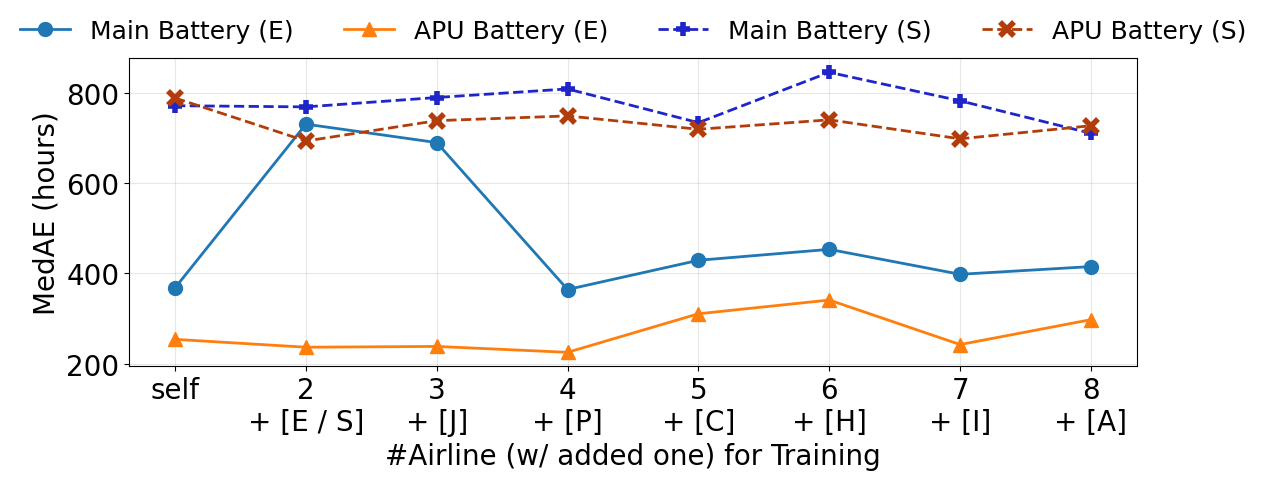

In [31]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20})
plot_atas = [243201, 243203]

df_plot = df_acc_ops[df_acc_ops["ata"].isin(plot_atas)].copy()
df_plot = df_plot.sort_values(["ata", "num_ops"])

df_plot2 = df_acc_ops_skw[df_acc_ops_skw["ata"].isin(plot_atas)].copy()
df_plot2 = df_plot2.sort_values(["ata", "num_ops"])

# ops 컬럼이 list 형태라고 가정: ['EDV'], ['EDV', 'SKW'], ...
def make_x_label(row):
    ops = row["ops"]
    num_ops = int(row["num_ops"])

    if isinstance(ops, str):
        # ops가 문자열로 저장된 경우 대비
        ops = ops.strip("[]").replace("'", "").split(", ")
    
    if num_ops == 1:
        return f"self"
    elif num_ops == 2:
        return f"2\n+ [E / S]"
    else:
        added_op = ops[-1]
        return f"{num_ops}\n+ [{added_op[0]}]"

label_df = (
    df_plot[["num_ops", "ops"]]
    .drop_duplicates(subset=["num_ops"])
    .sort_values("num_ops")
)

x_labels = label_df.apply(make_x_label, axis=1).tolist()
x_ticks = label_df["num_ops"].tolist()

plt.figure(figsize=(13, 4))

markers = ['o', '^', '+', 'x']
ata_names = ['Main Battery (E)', 'APU Battery (E)', 'Main Battery (S)', 'APU Battery (S)']
colors = ['tab:blue', 'tab:orange', "#1f25c8", "#b33d0a"]

for i, ata in enumerate(plot_atas):
    df_t = df_plot[df_plot["ata"] == ata].sort_values("num_ops")
    plt.plot(
        df_t["num_ops"],
        df_t["mdae"],
        marker=markers[i],
        color=colors[i],
        markersize=10,
        linestyle='-',
        linewidth=2,
        label=ata_names[i]
    )

for i, ata in enumerate(plot_atas):
    df_t2 = df_plot2[df_plot2["ata"] == ata].sort_values("num_ops")
    plt.plot(
        df_t2["num_ops"],
        df_t2["mdae"],
        marker=markers[i+2],
        color=colors[i+2],
        markersize=10,
        markeredgewidth=4,
        linestyle='--',
        linewidth=2,
        label=ata_names[i+2]
    )

plt.xticks(x_ticks, x_labels)
plt.xlabel("#Airline (w/ added one) for Training")
plt.ylabel("MedAE (hours)")
plt.legend(ncols=4, loc='upper center', bbox_to_anchor=(0.5, 1.2), frameon=False, fontsize=18)
plt.grid(True, alpha=0.3)
# plt.tight_layout()
plt.savefig('./png/varying_airline.png', bbox_inches='tight')

plt.show()

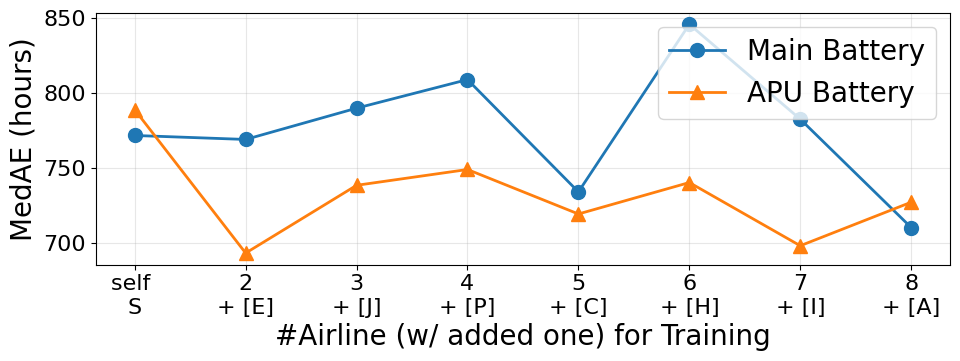

In [238]:
import matplotlib.pyplot as plt

plot_atas = [243201, 243203]

df_plot = df_acc_ops_skw[df_acc_ops_skw["ata"].isin(plot_atas)].copy()
df_plot = df_plot.sort_values(["ata", "num_ops"])

# ops 컬럼이 list 형태라고 가정: ['EDV'], ['EDV', 'SKW'], ...
def make_x_label(row):
    ops = row["ops"]
    num_ops = int(row["num_ops"])

    if isinstance(ops, str):
        # ops가 문자열로 저장된 경우 대비
        ops = ops.strip("[]").replace("'", "").split(", ")
    
    if num_ops == 1:
        return f"self \n{ops[0][0]}"
    else:
        added_op = ops[-1]
        return f"{num_ops}\n+ [{added_op[0]}]"

label_df = (
    df_plot[["num_ops", "ops"]]
    .drop_duplicates(subset=["num_ops"])
    .sort_values("num_ops")
)

x_labels = label_df.apply(make_x_label, axis=1).tolist()
x_ticks = label_df["num_ops"].tolist()

plt.figure(figsize=(10, 4))

markers = ['o', '^']
ata_names = ['Main Battery', 'APU Battery']
for i, ata in enumerate(plot_atas):
    df_t = df_plot[df_plot["ata"] == ata].sort_values("num_ops")
    plt.plot(
        df_t["num_ops"],
        df_t["mdae"],
        marker=markers[i],
        markersize=10,
        linewidth=2,
        label=ata_names[i]
    )

plt.xticks(x_ticks, x_labels)
plt.xlabel("#Airline (w/ added one) for Training")
plt.ylabel("MedAE (hours)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('./png/varying_airline_skw.png', bbox_inches='tight')

plt.show()

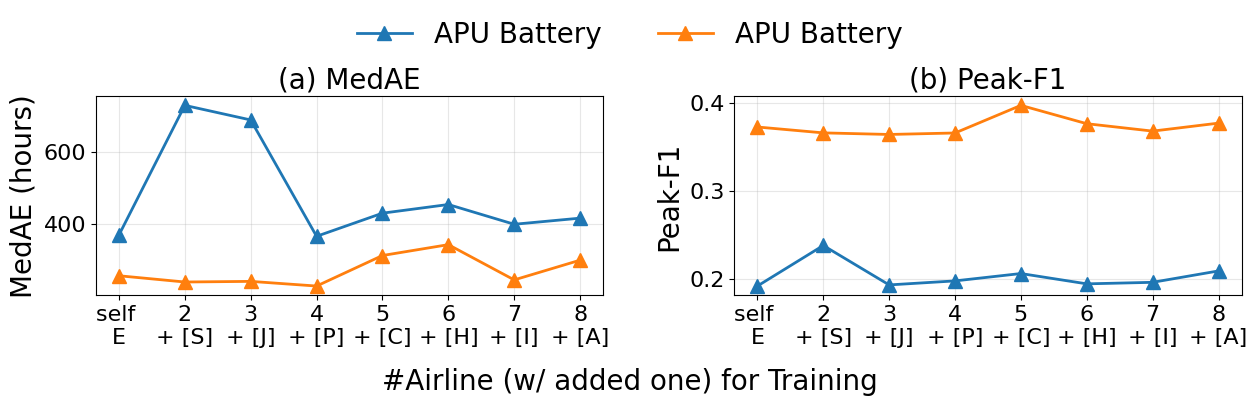

In [233]:
import matplotlib.pyplot as plt

plot_atas = [243201, 243203]
markers = ['o', '^']
ata_names = ['Main Battery', 'APU Battery']

df_plot = df_acc_ops[df_acc_ops["ata"].isin(plot_atas)].copy()
df_plot = df_plot.sort_values(["ata", "num_ops"])

def make_x_label(row):
    ops = row["ops"]
    num_ops = int(row["num_ops"])

    if isinstance(ops, str):
        ops = ops.strip("[]").replace("'", "").split(", ")

    if num_ops == 1:
        return f"self \n{ops[0][0]}"
    else:
        added_op = ops[-1]
        return f"{num_ops}\n+ [{added_op[0]}]"

label_df = (
    df_plot[["num_ops", "ops"]]
    .drop_duplicates(subset=["num_ops"])
    .sort_values("num_ops")
)

x_labels = label_df.apply(make_x_label, axis=1).tolist()
x_ticks = label_df["num_ops"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)

for ata in plot_atas:
    df_t = df_plot[df_plot["ata"] == ata].sort_values("num_ops")

    axes[0].plot(
        df_t["num_ops"],
        df_t["mdae"],
        marker=markers[i],
        markersize=10,
        linewidth=2,
        label=ata_names[i]
    )

    axes[1].plot(
        df_t["num_ops"],
        df_t["F1"],
        marker=markers[i],
        markersize=10,
        linewidth=2,
        label=ata_names[i]
    )

axes[0].set_title("(a) MedAE", fontsize=20)
# axes[0].set_xlabel("#Airline (w/ added one) for Training")
axes[0].set_ylabel("MedAE (hours)")
axes[0].grid(True, alpha=0.3)
handles, labels = axes[0].get_legend_handles_labels()

axes[1].set_title("(b) Peak-F1", fontsize=20)
# axes[1].set_xlabel("#Airline (w/ added one) for Training")
axes[1].set_ylabel("Peak-F1")
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels)
    # ax.legend(title="ATA")

fig.supxlabel("#Airline (w/ added one) for Training", fontsize=20, y=0.10)
fig.legend(handles, labels, ncols=2, loc='upper center', bbox_to_anchor=(0.5, 1.1), frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
# sel_ata = 243201
# target_atas_all= [243201, 324301, 344401, 215206, 243203, 253203, 313301, 324101, 324201, 324101, 335141, 722110]
target_atas_all= [243201, 324301,  243203, 313301, 344401, 324201]
ata_names = ['Main \nBattery', 'Break \nAssembly', 'APU \nBattery', 'Quick \nAccess \nRecorder', 'Radio \nTransceiver', 'Nose \nWheel &\nTire \nAssembly']
# target_atas_all = np.sort(target_atas_all)

dir1 = '/home/parkj182/research/MHI-2025/mhi/test_result_up/'
filelist= os.listdir(dir1)
files = [f for f in filelist if f.startswith('UP_TCN_ops_EDV')]
dir2 = '/home/parkj182/research/MHI-2025/mhi/test_result_logit/'
filelist2= os.listdir(dir2)
file_tcns = [f for f in filelist2 if 'TCN_AttenMulti' in f]
file_tsts = [f for f in filelist2 if 'TSTMulti' in f]

df_acc_all = pd.DataFrame(columns= ['ata', 'name', 'method', 'rem_un', 'rem_sc'] + peak_adj_columns)
for ata, ata_name in zip(target_atas_all, ata_names):
    methods, scores, labels, mdae, mdape, rem_uns, rem_scs, nums = [], [], [], [], [], [], [], []
    for f in files:
        match = re.search(r'_ata_(\d+)', f)
        if match:
            ata_num = int(match.group(1))
            if ata_num == ata:
                print(ata_num, f)
                df_up_ata = pd.read_csv(dir1+f, index_col=None)
                df_up_ata_rev, md, mdp, rem_un, rem_sc = revise_prediction(df_up_ata, ata, df_rep_train, pred='mu_f', exclude='all')
                methods.append('CALE')
                # scaler = MinMaxScaler()
                # scores.append(scaler.fit_transform(df_up_ata_rev['logit_f'].to_numpy().reshape(-1,1)))
                scores.append(df_up_ata_rev['logit_f'].to_numpy())
                labels.append(df_up_ata_rev['REMOVAL_TYPE_CODE'].apply(lambda x: 1 if x == 'U' else 0).to_numpy())
                mdae.append(md)
                mdape.append(mdp)
                # mdae_all.append(md_all)
                # mdape_all.append(mdp_all)
                rem_uns.append(rem_un)
                rem_scs.append(rem_sc)
                nums.append(len(df_up_ata_rev))
                break    

    for f in file_tcns:
        match = re.search(r'_ata_(\d+)', f)
        if match:
            ata_num = int(match.group(1))
            if ata_num == ata:
                print(ata_num, f)
                df_tcn_ata = pd.read_csv(dir2+f, index_col=None)
                if 'FH_MH_CNN' in df_tcn_ata.columns:
                    df_tcn_ata['FH_MH_TCN'] = df_tcn_ata['FH_MH_CNN']
                df_tcn_ata_f = df_tcn_ata.merge(
                    df_up_ata[key_cols].drop_duplicates(),
                    on=key_cols,
                    how='inner'
                )
                df_tcn_ata_rev, md, mdp, rem_un, rem_sc = revise_prediction(df_tcn_ata_f, ata, df_rep_train, pred='FH_MH_TCN')
                methods.append('TCN')
                # scaler = MinMaxScaler()
                # scores.append(scaler.fit_transform(df_tcn_ata_rev['u_pred'].to_numpy().reshape(-1,1)))
                scores.append(df_tcn_ata_f['u_pred'].to_numpy())
                labels.append(df_tcn_ata_f['REMOVAL_TYPE_CODE'].apply(lambda x: 1 if x == 'U' else 0).to_numpy())
                mdae.append(md)
                mdape.append(mdp)
                # mdae_all.append(md_all)
                # mdape_all.append(mdp_all)
                rem_uns.append(rem_un)
                rem_scs.append(rem_sc)
                nums.append(len(df_tcn_ata_rev))
                break
    for f in file_tsts:
        match = re.search(r'_ata_(\d+)', f)
        if match:
            ata_num = int(match.group(1))
            if ata_num == ata:
                print(ata_num, f)
                df_tst_ata = pd.read_csv(dir2+f, index_col=None)
                df_tst_ata_f = df_tst_ata.merge(
                    df_up_ata[key_cols].drop_duplicates(),
                    on=key_cols,
                    how='inner'
                )
                df_tst_ata_rev, md, mdp, rem_un, rem_sc = revise_prediction(df_tst_ata_f, ata, df_rep_train, pred='FH_MH_TST')
                methods.append('TST')
                # scaler = MinMaxScaler()
                # scores.append(scaler.fit_transform(df_tst_ata_rev['u_pred'].to_numpy().reshape(-1,1)))
                scores.append(df_tst_ata_f['u_pred'].to_numpy())
                labels.append(df_tst_ata_f['REMOVAL_TYPE_CODE'].apply(lambda x: 1 if x == 'U' else 0).to_numpy())
                mdae.append(md)
                mdape.append(mdp)
                # mdae_all.append(md_all)
                # mdape_all.append(mdp_all)
                rem_uns.append(rem_un)
                rem_scs.append(rem_sc)
                nums.append(len(df_tst_ata_rev))
                break
    
    df_t = result_f1_acc(methods, scores, labels)
    df_t['ata'] = ata
    df_t['name'] = ata_name
    df_t['mdae'] = mdae
    df_t['mdape'] = mdape
    # df_t['mdae_all'] = mdae_all
    # df_t['mdape_all'] = mdape_all
    df_t['rem_un'] = rem_uns
    df_t['rem_sc'] = rem_scs
    df_t['nums'] = nums
    df_t['num'] = [len(df_up_ata_rev)/len(df_up_ata)*100, len(df_tcn_ata_rev)/len(df_tcn_ata_f)*100, len(df_tst_ata_rev)/len(df_tst_ata_f)*100]
    df_t['num_org'] = [len(df_up_ata_rev), len(df_tcn_ata_rev), len(df_tst_ata_rev)]
    df_acc_all = pd.concat([df_acc_all, df_t])


In [160]:
all_operators = ['EDV', 'CLH','HXA', 'IBX', 'ANE', 'JZA', 'SKW', 'PSY']
target_atas_all= [243201, 324301,  243203, 313301, 344401, 324201]
df_rep_ops = df_rep[df_rep['OPERATOR_CODE'].isin(all_operators)]


In [162]:
len(df_rep_ops), len(set(df_rep_ops['AC_SN'].dropna())), len(set(df_rep_ops['OPERATOR_CODE'].dropna())), len(set(df_rep_ops['ATA_NUMBER'].dropna()))

(913522, 678, 8, 856)

In [236]:
len(set(df_rep_ops['PART_SN'].dropna()))

281310

In [164]:
len(df_rep), len(set(df_rep['AC_SN'].dropna())), len(set(df_rep['OPERATOR_CODE'].dropna())), len(set(df_rep['ATA_NUMBER'].dropna()))

(1855430, 901, 51, 1205)

In [235]:
len(set(df_rep['PART_SN'].dropna())), len(set(df_rep['PART_NO'].dropna()))

(482441, 4924)

In [73]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_up_ata['logit_f_s'] = scaler.fit_transform(df_up_ata[['logit_f']])

In [41]:
dfs[0]

,Unnamed: 0.1,PART_NO,PART_SN,AC_SN,INSTALL_DATE,OPERATOR_CODE,ATA_NUMBER,ATA_CHAPTER_x,ATA_SECTION_x,ATA_COMPONENT_x,...,alpha,logit,y_ac,y_pn,mu_f,sigma_f,alpha_f,logit_f,y_ac_f,y_pn_f
1,1,25255000,09052001A8EA8,10021,2023-07-24,PSY,243201,24,32,1,...,0.000000e+00,0.617408,978.635488,3950.965802,745.003437,607.237836,0.000000e+00,0.813235,872.982472,6462.277022
2,2,25255000,09052001DE6A8,10018,2023-08-23,PSY,243201,24,32,1,...,4.679310e-32,0.417733,1198.243004,3950.966008,908.814344,705.612891,2.933288e-34,0.710649,1081.914865,6548.495870
3,3,25255000,0905200149D7A,10018,2023-12-10,PSY,243201,24,32,1,...,0.000000e+00,0.542321,1366.950556,3950.965861,1064.249604,830.392165,0.000000e+00,1.057464,1167.644068,6547.215238
4,4,25255000,09052001A8EA8,10018,2024-01-04,PSY,243201,24,32,1,...,0.000000e+00,0.452802,1075.845190,3950.966067,852.281296,677.801956,0.000000e+00,0.897336,1031.084695,6500.351652
5,5,25255000,09052001D96DA,10018,2024-09-24,PSY,243201,24,32,1,...,9.381222e-27,0.314965,901.795289,3950.965979,748.172884,584.654677,6.375189e-29,0.403307,970.025647,6544.615060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1482,1482,24637000,506176,15493,2025-01-06,JZA,243201,24,32,1,...,0.000000e+00,-0.261743,1054.905261,3950.965743,665.522121,479.238082,0.000000e+00,-0.839510,959.518824,6553.606607
1483,1483,25255000,09052001E0990,15462,2021-10-06,PSY,243201,24,32,1,...,0.000000e+00,-0.745131,1130.484717,3950.965861,858.973173,617.369585,0.000000e+00,-0.270865,1070.959887,6545.260329
1501,1501,24637000,508764,15485,2023-05-11,EDV,243201,24,32,1,...,5.404975e-13,-1.749864,758.518358,3950.966097,323.075410,321.785760,7.113244e-14,-1.815295,752.374158,6543.401879
1529,1529,25255000,09052000FF0E3,15477,2024-01-24,PSY,243201,24,32,1,...,0.000000e+00,0.688321,1536.862222,3950.965448,1055.475489,791.522777,0.000000e+00,0.706608,1153.332778,6478.635623


['UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv', 'UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324301_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv', 'UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_344401_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv', 'UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_215206_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv', 'UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243203_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv', 'UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_313301_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv', 'UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324101_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv', 'UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324201_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv', 'UP_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_335141_CONFIG_2_model_TCNAtten_seqata_3_seqsn_3_b_16.csv', 'UP_TCN_ops_EDV_CLH_HXA_IBX

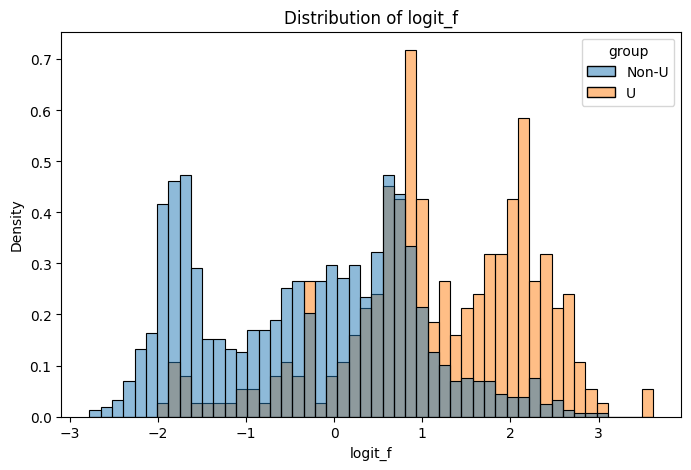

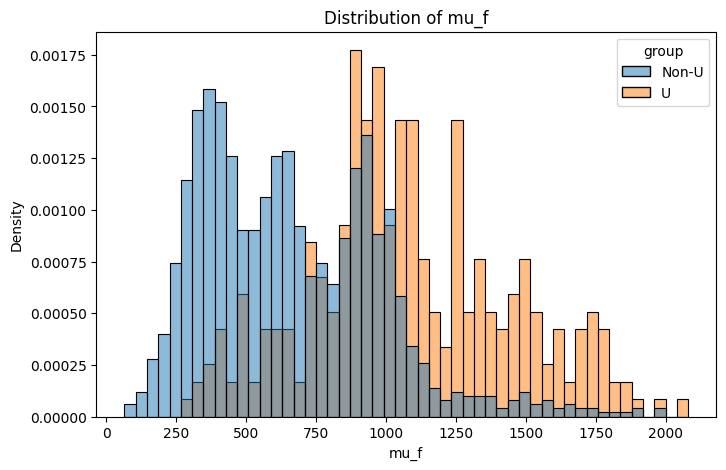

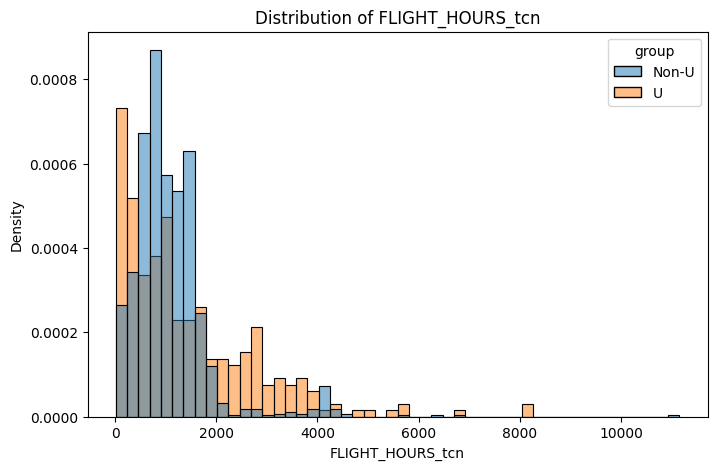

In [ ]:
sel_ata = 243201
dir1 = '/home/parkj182/research/MHI-2025/mhi/test_result_up/'
filelist= os.listdir(dir1)
files = [f for f in filelist if f.startswith('UP_TCN_ops_EDV')]
print(files)

palette = {
    'U': 'tab:orange',
    'Non-U': 'tab:blue'
}

for f in files:
    match = re.search(r'_ata_(\d+)', f)
    if match:
        ata_num = int(match.group(1))
        print(ata_num, f)
        df_up_ata = pd.read_csv(dir1+f, index_col=None)
        break

# df_up_ata.head()

df_up_au = df_up_ata[df_up_ata['REMOVAL_TYPE_CODE'] == 'U'].copy()
err_up = abs(df_up_au['mu_f']-df_up_au['FLIGHT_HOURS_tcn'])
print(np.median(err_up), np.median(abs(df_up_ata['mu_f']-df_up_ata['FLIGHT_HOURS_tcn'])))

# df_plot = df_up_ata[['REMOVAL_TYPE_CODE', 'logit_f']].dropna()
# df_plot['group'] = df_plot['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')

# plt.figure(figsize=(8,5))
# sns.histplot(data=df_plot, x='logit_f', hue='group', bins=50, stat='density', common_norm=False, alpha=0.5,palette=palette)

# plt.title('Distribution of logit_f')
# plt.show()

## Mu
# df_plot = df_up_ata[['REMOVAL_TYPE_CODE', 'mu_f']].dropna()
# df_plot['group'] = df_plot['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')
# 
# plt.figure(figsize=(8,5))
# sns.histplot(data=df_plot, x='mu_f', hue='group', bins=50, stat='density', common_norm=False, alpha=0.5,palette=palette)
# 
# plt.title('Distribution of mu_f')
# plt.show()

## True FH
df_up_ata
# df_plot = df_up_ata[['REMOVAL_TYPE_CODE', 'FLIGHT_HOURS_tcn']].dropna()
# df_plot['group'] = df_plot['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')

# plt.figure(figsize=(8,5))
# sns.histplot(data=df_plot, x='FLIGHT_HOURS_tcn', hue='group', bins=50, stat='density', common_norm=False, alpha=0.5,palette=palette)

# plt.title('Distribution of FLIGHT_HOURS_tcn')
# plt.show()



# dir2 = '/home/parkj182/research/MHI-2025/mhi/test_results_all/'
# filelist2 = os.listdir(dir2)
# files2 = [f for f in filelist2 if f.startswith(f'FL_TCN_ops_allpossible__ata_{sel_ata}')]
# df_fl = pd.read_csv(dir2+files2[0], index_col=None)
# df_fl.head()
# 
# filelist2

# df_fl1 = df_fl[df_fl['REMOVAL_TYPE_CODE'] == 'U'].copy()
# err2 = abs(df_fl1['mu_f']-df_fl1['FLIGHT_HOURS_tcn'])
# 
# print(np.median(err2))

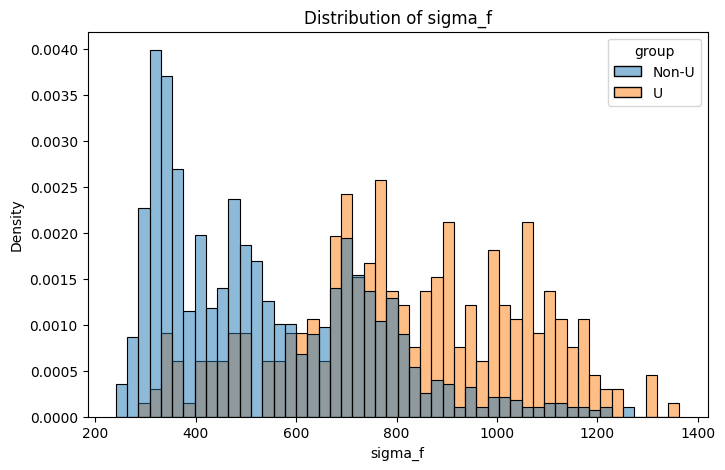

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_up_ata[['REMOVAL_TYPE_CODE', 'sigma_f']].dropna()
df_plot['group'] = df_plot['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')

plt.figure(figsize=(8,5))
sns.histplot(data=df_plot, x='sigma_f', hue='group', bins=50, stat='density', common_norm=False, alpha=0.5,palette=palette)

plt.title('Distribution of sigma_f')
plt.show()

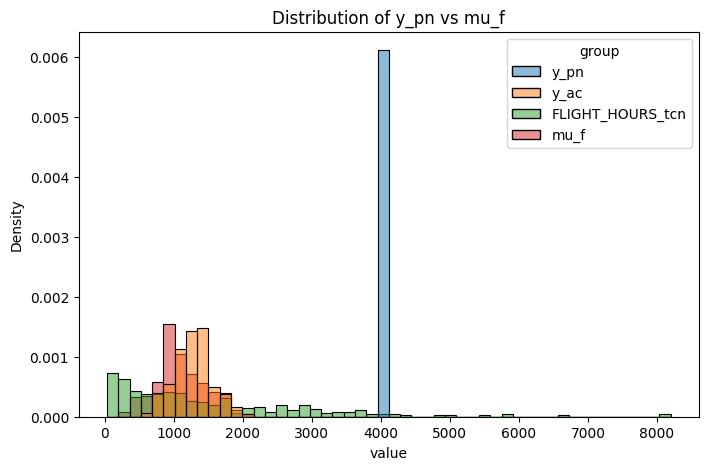

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_plot = pd.concat([
    df_up_au[['y_pn']].rename(columns={'y_pn': 'value'}).assign(group='y_pn'),
    df_up_au[['y_ac']].rename(columns={'y_ac': 'value'}).assign(group='y_ac'),
    df_up_au[['FLIGHT_HOURS_tcn']].rename(columns={'FLIGHT_HOURS_tcn': 'value'}).assign(group='FLIGHT_HOURS_tcn'), 
    df_up_au[['mu_f']].rename(columns={'mu_f': 'value'}).assign(group='mu_f')
]).dropna()

plt.figure(figsize=(8,5))
sns.histplot(data=df_plot, x='value', hue='group',
             bins=50, stat='density', common_norm=False, alpha=0.5)

plt.title('Distribution of y_pn vs mu_f')
plt.show()

#### Read data: comparisons
- (1) TCN_Atten. with classification head
- (2) Time Series Transformer with classification head

In [33]:
dir1 = '/home/parkj182/research/MHI-2025/mhi/test_result_logit/'
filelist= os.listdir(dir1)
print(filelist)
# files = [f for f in filelist if f.startswith('UP_')]
file_tcns = [f for f in filelist if 'TCN_AttenMulti' in f]
file_tsts = [f for f in filelist if 'TSTMulti' in f]
file_tsts
# file_tcns

['ata4_Multi_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243201_CONFIG_2_model_TCN_AttenMulti_seqata_3_seqsn_3_b_16.csv', 'ata4_Multi_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324301_CONFIG_2_model_TCN_AttenMulti_seqata_3_seqsn_3_b_16.csv', 'ata4_Multi_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_344401_CONFIG_2_model_TCN_AttenMulti_seqata_3_seqsn_3_b_16.csv', 'ata4_Multi_TCN_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_215206_CONFIG_2_model_TCN_AttenMulti_seqata_3_seqsn_3_b_16.csv', 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243201_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv', 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324301_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv', 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_344401_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv', 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_215206_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv', 'ata4_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__

['ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243201_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv',
 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324301_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv',
 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_344401_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv',
 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_215206_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv',
 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_243203_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv',
 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_313301_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv',
 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324101_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv',
 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_324201_CONFIG_2_model_TSTMulti_seqata_3_seqsn_3_b_16.csv',
 'ata4_Multi_TST_ops_EDV_CLH_HXA_IBX_ANE_JZA_SKW_PSY__ata_335141

In [34]:
selected_ata  =243201
for f in file_tcns:
    match = re.search(r'_ata_(\d+)', f)
    if match:
        ata_num = int(match.group(1))
        print(ata_num)
        df_tcn_ata = pd.read_csv(dir1+f, index_col=None)
        break
for f in file_tsts:
    match = re.search(r'_ata_(\d+)', f)
    if match:
        ata_num = int(match.group(1))
        print(ata_num)
        df_tst_ata = pd.read_csv(dir1+f, index_col=None)
        break

df_tcn_au = df_tcn_ata[df_tcn_ata['REMOVAL_TYPE_CODE'] == 'U'].copy()
df_tst_au = df_tst_ata[df_tst_ata['REMOVAL_TYPE_CODE'] == 'U'].copy()


err_tcn = abs(df_tcn_au['FH_MH_CNN']-df_tcn_au['FLIGHT_HOURS_tcn'])
err_tst = abs(df_tst_au['FH_MH_TST']-df_tst_au['FLIGHT_HOURS_tcn'])

print(np.median(err_tcn), np.median(abs(df_tcn_ata['FH_MH_CNN']-df_tcn_ata['FLIGHT_HOURS_tcn'])))
print(np.median(err_tst), np.median(abs(df_tst_ata['FH_MH_TST']-df_tst_ata['FLIGHT_HOURS_tcn'])))

243201
243201
789.2480154469986 332.00173690595574
738.1865116995651 347.08174752809987


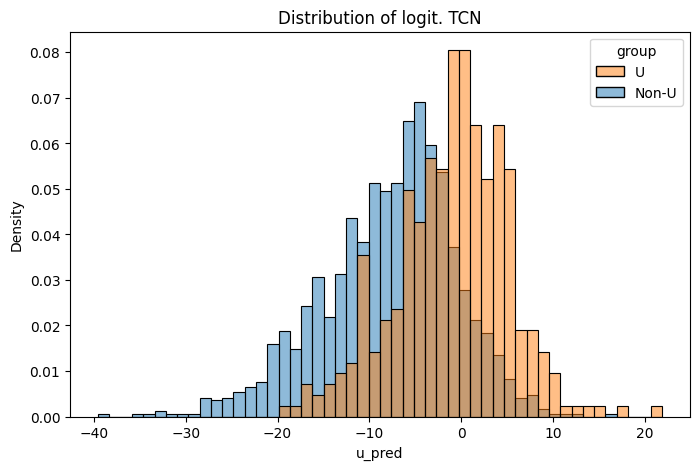

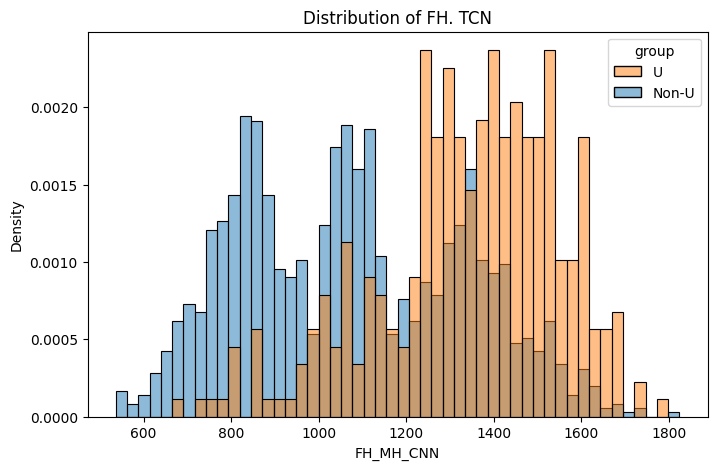

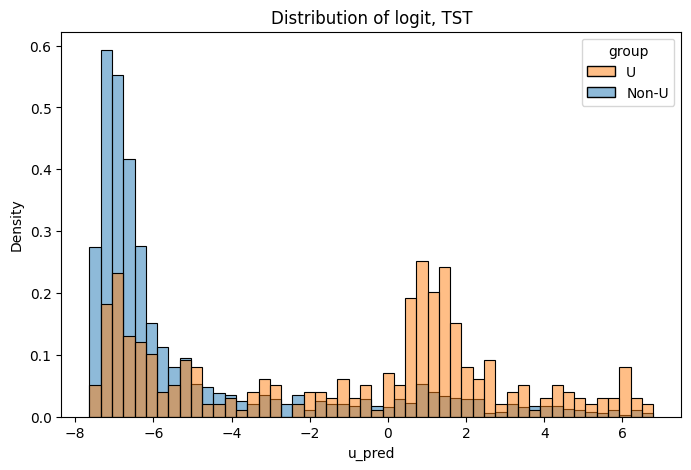

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_tcn_ata[['REMOVAL_TYPE_CODE', 'u_pred']].dropna()
df_plot['group'] = df_plot['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')

plt.figure(figsize=(8,5))
sns.histplot(data=df_plot, x='u_pred', hue='group', bins=50, stat='density', common_norm=False, alpha=0.5,palette=palette)

plt.title('Distribution of logit. TCN')
plt.show()

df_plot = df_tcn_ata[['REMOVAL_TYPE_CODE', 'FH_MH_CNN']].dropna()
df_plot['group'] = df_plot['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')

plt.figure(figsize=(8,5))
sns.histplot(data=df_plot, x='FH_MH_CNN', hue='group', bins=50, stat='density', common_norm=False, alpha=0.5,palette=palette)

plt.title('Distribution of FH. TCN')
plt.show()

### TST
df_plot = df_tst_ata[['REMOVAL_TYPE_CODE', 'u_pred']].dropna()
df_plot['group'] = df_plot['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')

plt.figure(figsize=(8,5))
sns.histplot(data=df_plot, x='u_pred', hue='group', bins=50, stat='density', common_norm=False, alpha=0.5,palette=palette)

plt.title('Distribution of logit, TST')
plt.show()

#### Draw lights

In [ ]:
def get_selected_stats_preds_all(model_sel, df_test, target_atas, base_dir, testing_date, chk_date, op_data, top_sel = 1, seq_len=5, embed=True):
    y_pred_all = []
    for target_ata in target_atas:
        print('TARGET ATA: ', target_ata)
        df_rep_all = pd.DataFrame()
        nums, avg_fh, abs_err, median_err, err_r, m_err_r, m_err_mad = [], [], [], [], [], [], []
        y_df_ops = []

        # df_op = df_rep.groupby('OPERATOR_CODE').get_group(sel_op)
        # df_rep_tr = df_op[df_op['INSTALL_DATE'] > chk_date]
        # df_rep_tr = df_rep_tr[df_rep_tr['REMOVAL_DATE'] < testing_date]
        # print(f'[{sel_op}]')
        # display(df_rep.groupby('ATA_NUMBER').count()['PART_NO'])
        # df_stats = get_valid_ata_lists_op(df_rep, sel_op, chk_date, validate_date, testing_date, end_date)
        # df_rep_ata = df_rep_tr.groupby('ATA_NUMBER').get_group(target_ata)
        # ops = df_rep_ata.groupby('OPERATOR_CODE').count().index
        # if len(ops) >1:
            # print(df_rep_ata.groupby('OPERATOR_CODE').count().index)
            # df_rep_ata['OPERATOR_CODE'] = sel_op
            # print(df_rep_ata.groupby('OPERATOR_CODE').count().index)
        y_df = pd.read_csv(f'./data_ata4/icde_test_ata_{sel_op}_{target_ata}_len_{seq_len}_embed_{embed}.csv')
        # try:
            # y_df = pd.read_csv(f'./update_data/test_{target_ata}_{sel_op}_{testing_date.year}_{testing_date.month}_{model_sel}.csv', index_col=None)
        # except:
            # y_df = pd.read_csv(f'./update_data/test_{target_ata}_{sel_op}_{testing_date.year}_{testing_date.month}_both_{model_sel}.csv', index_col=None)
        y_df_ops.append(y_df)
        y_df2 = y_df[['AC_SN', 'OPERATOR_CODE', 'FLIGHT_HOURS', 'FH_org', f'{model_sel}']]
        y_df2['abs_err'] = abs(y_df2['FLIGHT_HOURS'] - y_df2[f'{model_sel}'])
        y_df2['err_r'] = y_df2['abs_err'] / y_df2['FLIGHT_HOURS']
        y_df3 = y_df2.sort_values(by='abs_err')
        chk_err = np.sort(y_df3['abs_err'])
        chk_err = chk_err[:int(len(chk_err)*top_sel)]
        abs_err.append(np.mean(chk_err))
        median_err.append(np.median(chk_err))
        chk_err_r = np.array(y_df3['err_r'])[:int(len(y_df3)*top_sel)]
        err_r.append(np.mean(chk_err_r))
        m_err_r.append(np.median(chk_err_r))
        
        m_err_mad.append(np.median(np.abs(chk_err_r - np.median(chk_err_r))))
        df_rep_all = pd.concat([df_rep_all, df_rep_ata])
        nums.append(len(df_rep_ata))
        avg_fh.append(np.mean(df_rep_ata['FLIGHT_HOURS']))


        y_pred_all.append(y_df_ops)
        op_data[f'{target_ata}_num'] = nums
        op_data[f'{target_ata}_avg_fh'] = avg_fh
        op_data[f'{target_ata}_abs_err'] = abs_err
        op_data[f'{target_ata}_median_err'] = median_err
        op_data[f'{target_ata}_err_r'] = err_r
        op_data[f'{target_ata}_m_err_r'] = m_err_r
        op_data[f'{target_ata}_m_err_mad'] = m_err_mad


    result = op_data.round(2)


    return result, y_pred_all, df_rep_all

def get_selected_stats_preds(model_sel, df_rep, target_atas, selected_operators, base_dir, testing_date, chk_date, op_data, top_sel = 1, seq_len=5, embed=True):
    y_pred_all = []
    for target_ata in target_atas:
        print('TARGET ATA: ', target_ata)
        df_rep_all = pd.DataFrame()
        nums, avg_fh, abs_err, median_err, err_r, m_err_r, m_err_mad = [], [], [], [], [], [], []
        y_df_ops = []
        for ii, sel_op in enumerate(selected_operators):

            df_op = df_rep.groupby('OPERATOR_CODE').get_group(sel_op)

            df_rep_tr = df_op[df_op['INSTALL_DATE'] > chk_date]
            df_rep_tr = df_rep_tr[df_rep_tr['REMOVAL_DATE'] < testing_date]

            # print(f'[{sel_op}]')
            # display(df_rep.groupby('ATA_NUMBER').count()['PART_NO'])

            # df_stats = get_valid_ata_lists_op(df_rep, sel_op, chk_date, validate_date, testing_date, end_date)
            df_rep_ata = df_rep_tr.groupby('ATA_NUMBER').get_group(target_ata)

            ops = df_rep_ata.groupby('OPERATOR_CODE').count().index
            if len(ops) >1:
                # print(df_rep_ata.groupby('OPERATOR_CODE').count().index)
                df_rep_ata['OPERATOR_CODE'] = sel_op
                # print(df_rep_ata.groupby('OPERATOR_CODE').count().index)

            y_df = pd.read_csv(f'./data_ata4/icde_test_ata_{sel_op}_{target_ata}_len_{seq_len}_embed_{embed}.csv')
            # try:
                # y_df = pd.read_csv(f'./update_data/test_{target_ata}_{sel_op}_{testing_date.year}_{testing_date.month}_{model_sel}.csv', index_col=None)

            # except:
                # y_df = pd.read_csv(f'./update_data/test_{target_ata}_{sel_op}_{testing_date.year}_{testing_date.month}_both_{model_sel}.csv', index_col=None)

            y_df_ops.append(y_df)
            y_df2 = y_df[['AC_SN', 'OPERATOR_CODE', 'FLIGHT_HOURS', 'FH_org', f'{model_sel}']]
            y_df2['abs_err'] = abs(y_df2['FLIGHT_HOURS'] - y_df2[f'{model_sel}'])
            y_df2['err_r'] = y_df2['abs_err'] / y_df2['FLIGHT_HOURS']

            y_df3 = y_df2.sort_values(by='abs_err')
            chk_err = np.sort(y_df3['abs_err'])
            chk_err = chk_err[:int(len(chk_err)*top_sel)]

            abs_err.append(np.mean(chk_err))
            median_err.append(np.median(chk_err))

            chk_err_r = np.array(y_df3['err_r'])[:int(len(y_df3)*top_sel)]
            err_r.append(np.mean(chk_err_r))
            m_err_r.append(np.median(chk_err_r))
            
            m_err_mad.append(np.median(np.abs(chk_err_r - np.median(chk_err_r))))

            df_rep_all = pd.concat([df_rep_all, df_rep_ata])
            nums.append(len(df_rep_ata))
            avg_fh.append(np.mean(df_rep_ata['FLIGHT_HOURS']))

        y_pred_all.append(y_df_ops)
        op_data[f'{target_ata}_num'] = nums
        op_data[f'{target_ata}_avg_fh'] = avg_fh
        op_data[f'{target_ata}_abs_err'] = abs_err
        op_data[f'{target_ata}_median_err'] = median_err
        op_data[f'{target_ata}_err_r'] = err_r
        op_data[f'{target_ata}_m_err_r'] = m_err_r
        op_data[f'{target_ata}_m_err_mad'] = m_err_mad

    result = op_data.round(2)

    return result, y_pred_all, df_rep_all

def get_proportion_bar(model, y_pred_all, target_atas, selected_operators):
    bounds = [300, 700, 100000]
    # models = [f'{model_type}', f'{model_type}_{model_op}']
    # model = 'CNN'

    result = pd.DataFrame(columns=['ATA6', 'OP', 'Num', 'Avg',
                                    f'{model}_Err_avg', f'{model}_Err_std', f'{model}_avg_r', 
                                    f'{model}_300', f'{model}_300_err_r', f'{model}_700', f'{model}_700_err_r', f'{model}_100000', f'{model}_100000_err_r',
                                    f'{model}_700_err_c', f'{model}_top_70'
                                    ])

    ind = 0

    for target_ata, y_df_ops in zip(target_atas, y_pred_all):
        list_to_add = []
        for op, y_df in zip(selected_operators, y_df_ops):
            list_to_add = [target_ata, op, len(y_df), np.mean(y_df['FLIGHT_HOURS'])]

        # for model in models:
            y_df[f'{model}_err'] = abs(y_df['FLIGHT_HOURS'] - y_df[model])
            y_df[f'{model}_avg_r'] = y_df[f'{model}_err']/y_df['FLIGHT_HOURS']*100

            list_to_add += [np.mean(y_df[f'{model}_err']), np.std(y_df[f'{model}_err']), np.mean(y_df[f'{model}_avg_r'])]

            for bound in bounds:
                if bound <= bounds[1]:
                    d_t = y_df[y_df[f'{model}_err'] <= bound]
                if bound == bounds[1]:
                    d_t = d_t[d_t[f'{model}_err'] > bounds[0]]
                if bound == bounds[2]:
                    d_t = y_df[y_df[f'{model}_err'] > bounds[1]]

                d_t[f'{model}_{bound}_err_r'] = d_t[f'{model}_err']/d_t['FLIGHT_HOURS']*100
                list_to_add += [len(d_t), np.mean(d_t[f'{model}_{bound}_err_r'])]

            d_t2 = y_df[y_df[f'{model}_err']<= bounds[1]]
            d_t2[f'{model}_{bounds[1]}_err_c'] = d_t2[f'{model}_err']/d_t2['FLIGHT_HOURS']*100

            ## get Top 70%
            sorted_err = y_df.sort_values(by=f'{model}_err', ascending=True)
            sorted_err = sorted_err.iloc[:round(len(sorted_err)*0.7)]

            list_to_add += [np.mean(d_t2[f'{model}_{bounds[1]}_err_c']), np.mean(sorted_err[f'{model}_err']/y_df['FLIGHT_HOURS']*100)]

            result.loc[ind] = list_to_add
            ind +=1

    # result

    for bound in bounds:
        result[f'{model}_{bound}_r'] = result[f'{model}_{bound}']/result['Num']*100
    result[f'{model}_700_c'] = result[f'{model}_300_r'] + result[f'{model}_700_r']


    return result


def plot_light_bar(result, model, target_atas, save=True):
    target_ata_names = ['Main Battery', 'Break Assembly', 'Radio Transceiver', 'Dual Heat Exchanger']
    bounds = [300, 700, 100000]
    plt.rc('font', size=20)
    plt.rc('axes', labelsize=20)

    for bound in bounds:
        result[f'{model}_{bound}_r'] = result[f'{model}_{bound}']/result['Num']*100
    result[f'{model}_700_c'] = result[f'{model}_300_r'] + result[f'{model}_700_r']

    target_sort = f'{model}_700_c'
    colors = ['tab:green', 'gold', 'tab:red']


    # df_show = result.sort_values(by=target_sort, ascending=False)
    # df_show = df_show.sort_values(by='CNN_300_r', ascending=False)
    # df_show = df_show.round(2)
    result = result.round(1)


    fig, ax = plt.subplots(figsize=(20,4))
    w = 0.185
    p =[]

    # show_operators = ['EDV', 'HXA', 'IBX', 'SKW', 'PSY']
    show_operators = ['EDV', 'CLH',  'HXA', 'IBX','PSY']
    alpha_range = np.arange(len(show_operators)) - len(show_operators)/2 +0.5
    print(alpha_range)
    for sel_op, alpha in zip(show_operators, alpha_range):
        df_show = result.groupby('OP').get_group(sel_op)
        # df_show = df_show.sort_values(by=target_sort, ascending=False)
        bottom = np.zeros(len(df_show))
        for j, bound in enumerate(bounds):
            p.append(ax.bar(np.arange(len(df_show))+alpha*w, df_show[f'{model}_{bound}_r'], width=w-0.02, color=colors[j], bottom = bottom))
            df_show[f'{model}_{bound}_err_r'] = df_show[f'{model}_{bound}_err_r'].fillna(' ')
            if sel_op == 'PSY' and j ==0:
                ax.bar_label(p[-1], labels= df_show[f'{model}_{bound}_err_r'],label_type='center', padding=1, fontsize=15)
            elif sel_op == 'PSY' and j ==1:
                ax.bar_label(p[-1], labels= df_show[f'{model}_{bound}_err_r'],label_type='center', padding=6, fontsize=15)
            elif sel_op == 'CLH' and j ==1:
                ax.bar_label(p[-1], labels= df_show[f'{model}_{bound}_err_r'],label_type='center', padding=-5, fontsize=15)
            else:
                ax.bar_label(p[-1], labels= df_show[f'{model}_{bound}_err_r'],label_type='center', fontsize=15)
            bottom += df_show[f'{model}_{bound}_r']
        ax.bar_label(p[-1], labels=[sel_op[0] for i in range(len(df_show))])

    plt.legend((p[0][0], p[1][0], p[2][0]), ('< 300h', '< 700h', '> 700h'), ncol=3, bbox_to_anchor=(0.5, 1.20), loc='upper center', framealpha=0)
    print(len(target_atas), target_ata_names)
    plt.xticks(np.arange(len(target_atas)), target_ata_names)
    plt.xlabel('ATA6')
    plt.ylabel('Percentage (%)')
    # plt.title(f'{df_show.OP.iloc[0]}: Err. distribution (color) and Err. ratio (text), sorted by {models[1]}', pad=40)
    plt.ylim(0, 110)
    # plt.show()
    plt.margins(x=0.01,y=0.01)
    if save:
        plt.savefig(f'./png/ops_atas.png',bbox_inches='tight')
    else:
        plt.show()


In [1]:
import torch
import torch.nn as nn
from torch import optim
from torch.nn import functional as F
from models.mix_model import *

## For temporal use
m_cols = ['PART_NO', 'PART_SN', 'INSTALL_DATE', 'REMOVAL_DATE', 'REMOVAL_TYPE_CODE', 'ATA_NUMBER', 
          'AC_SN', 'OPERATOR_CODE', 'FLIGHT_HOURS', 'FLIGHT_CYCLES']

## Minimum flight hours for use
MIN_FH = 10
embed_dim = 128  ## <-- out_channel increase (both CNN and Attention)
num_heads = 8
OUT_LAYER = 1
STRIDE =1
KERNEL_SIZE = 2 ## <-- kernel size 
DROPOUT = 0.1
## for TCN data
sel_ones = 'all'
embedding_dim =8    ## for categorical embedding
revise=True
## Parameters for Transformer
input_dim = 2
d_model = 128    ## <--- increase
nhead = 8
num_encoder_layers = 4  ## <-- increase 
dim_feedforward = 256   ## <-- increase

seq_len_ata, seq_len_sn = 3, 3
target_atas = 243201
op_list = ['SKW']
op_grp = ['SKW']
base_dir = "/home/mhi/Data/dataset"
ac_model = 'CRJ700'

## Important datetime split
considered_date = datetime.datetime(2015,1,1)
latest_date = datetime.datetime(2025,10,1)
test_date = datetime.datetime(2023,3,1)

df_rep, df_util_diff = load_data(base_dir, MIN_FH, latest_date, ac_model)
df_process_data = get_selected_data(df_rep, df_util_diff, op_grp, target_atas)
deviation = 'inc'

## For TCN (ATA4) networks
X_train_nums, X_train_ones, y_train_list, X_test_nums, X_test_ones, y_test_list, df_test, df_train, pn_list = get_data_tcn(
    df_process_data, df_util_diff, int(target_atas), op_list, considered_date=considered_date, latest_date=latest_date, test_date=test_date, seq_len=seq_len_ata, embedding_dim=embedding_dim)

## For Transformer-encoder (PartSN) networks
X_U, y_U, X_S, y_S, X_US, y_US, X_test_sn, y_test_sn, y_test_type_sn, df_test_sn, df_train_sn = get_selected_data_pn(
    df_process_data, target_atas, op_grp, deviation, latest_date, test_date, seq_len=seq_len_sn)


## For duplicated datasets for two encoders (train & test)
print("[CHK] length of train and test ==> ", len(df_train), len(df_test), len(df_train_sn), len(df_test_sn))
if len(df_train) < 10 or len(df_train_sn) < 10:
    print(f'Not enough training set for {op_grp}. AC: {len(df_train)}, SN: {len(df_train_sn)}')
        
for col in m_cols:
    if col in ['INSTALL_DATE', 'REMOVAL_DATE']:
        df_train[col] = pd.to_datetime(df_train[col])   ## from TCN
        df_train_sn[col] = pd.to_datetime(df_train_sn[col]) ## from Transformer
        df_test[col] = pd.to_datetime(df_test[col])
        df_test_sn[col] = pd.to_datetime(df_test_sn[col])

    else:
        df_train[col] = df_train[col].astype(str)
        df_train_sn[col] = df_train_sn[col].astype(str)
        df_test[col] = df_test[col].astype(str)
        df_test_sn[col] = df_test_sn[col].astype(str)

# m_cols_rev= m_cols - ['FLIGHT_HOURS']
m_cols_rev = [m for m in m_cols if m!= 'FLIGHT_HOURS' ]
df_train = df_train.rename(columns={'FLIGHT_HOURS': 'FLIGHT_HOURS_tcn'})
df_train_sn = df_train_sn.rename(columns={'FLIGHT_HOURS': 'FLIGHT_HOURS_sn'})
df_test = df_test.rename(columns={'FLIGHT_HOURS': 'FLIGHT_HOURS_tcn'})
df_test_sn = df_test_sn.rename(columns={'FLIGHT_HOURS': 'FLIGHT_HOURS_sn'})
        

## For decoder & fine-tune
df_train_dup = df_train.merge(df_train_sn, how='inner', on=m_cols_rev)
df_test_dup = df_test.merge(df_test_sn, how='inner', on =m_cols_rev)

PNs: ['100064669', '100223520', '100223521', '100321796', '17561', '22835000', '24637000', '25255000', '9750W03501'] Index([243201, 243203, 243205, 243207], dtype='int32', name='ATA_NUMBER')


100%|██████████| 199/199 [00:09<00:00, 21.61it/s]


TEST and CHKS:  185 185
4
TRAIN:  915 915


ValueError: too many values to unpack (expected 9)

In [147]:
len(df_rep), len(set(df_rep['AC_SN'].dropna())), len(set(df_rep['OPERATOR_CODE'].dropna())), len(set(df_rep['ATA_NUMBER'].dropna()))

(1855430, 901, 51, 1205)

In [153]:
atas = df_rep['ATA_NUMBER'].dropna().to_list()
ata_lists = np.array(list(set(atas)))

In [158]:
len(set(df_util_diff['ac_sn'].dropna()))

2004

In [7]:
df_train[df_train['REMOVAL_TYPE_CODE']=='U']

,PART_NO,PART_SN,AC_SN,INSTALL_DATE,OPERATOR_CODE,ATA_NUMBER,ATA_CHAPTER,ATA_SECTION,ATA_COMPONENT,REMOVAL_DATE,...,CUML_CYCLES,ATA4,isU,reinstall_cnt,CUMULATIVE_FLIGHT_HOURS,CUMULATIVE_CYCLES,days,prev_fh,X_numeric,X_category
0,9750W03501,6104W0005,10009,2015-11-11,SKW,243201,24,32,1,2016-06-03,...,10930,2432,1,3.0,40130.125,26504.5,4.0,800.68,"[[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0....","[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
1,9750W03501,6307W0007,10010,2015-05-23,SKW,243201,24,32,1,2015-08-31,...,6196,2432,1,0.0,33105.22,22834.0,0.0,356.09,"[[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0....","[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
3,9750W03501,4359W0001,10010,2016-07-21,SKW,243201,24,32,1,2017-04-22,...,5755,2432,1,2.0,36267.924667,24847.933333,5.0,2674.14,"[[0.0, 0.0, 0.0, 22115.85483870986, 0.0], [356...","[[[tensor(-0.3379), tensor(1.3026), tensor(0.3..."
4,9750W03501,1343W0004,10011,2016-07-19,ASQ,243201,24,32,1,2017-11-20,...,6638,2432,1,2.0,39734.05,29847.0,0.0,2582.22,"[[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0....","[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
9,9750W03501,7243W0005,10042,2018-10-28,SKW,243201,24,32,1,2022-01-13,...,12448,2432,1,5.0,39918.539935,30219.256212,3.0,326.83,"[[0.0, 0.0, 0.0, 0.0, 0.0], [159.31, 50.149285...","[[[tensor(-0.3379), tensor(1.3026), tensor(0.3..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,9750W03501,7362W0015,15456,2019-11-19,SKW,243201,24,32,1,2020-12-09,...,10005,2432,1,4.0,3053.425484,2583.064516,2.0,1846.18,"[[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0....","[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
911,9750W03501,4317W0004,15456,2020-12-14,SKW,243201,24,32,1,2021-12-30,...,24162,2432,1,7.0,5421.96129,4567.354839,3.0,1149.83,"[[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0....","[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
912,9750W03501,6237W0004,15499,2021-09-08,SKW,243201,24,32,1,2022-02-10,...,20677,2432,1,9.0,2218.300714,1917.428571,3.0,5482.27,"[[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0....","[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."
913,9750W03501,191020014,15499,2022-02-10,SKW,243201,24,32,1,2022-06-25,...,3052,2432,1,2.0,2945.826667,2658.0,5.0,920.55,"[[0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0....","[[[tensor(0.), tensor(0.), tensor(0.), tensor(..."


In [8]:
df_train_sn[df_train_sn['REMOVAL_TYPE_CODE']=='U']

,level_0,Unnamed: 0,PART_NO,PART_SN,AC_SN,INSTALL_DATE,QTY,ATA_REPORTED,AC_MODEL,OPERATOR_CODE,...,diff_hours,diff_cycle,hour_per_cycle,CUMULATIVE_FLIGHT_HOURS,CUMULATIVE_CYCLES,days,cum_FH,cum_FC,X_hist,Y
2,2325,1010492,24637000,106646,10033,2005-01-10,1,243201.0,CRJ700,QXE,...,10.093333,6.766667,1.491626,8786.786667,6531.733333,3.0,3663.01,2690,"[[1129.68, 0.0], [1319.77, 0.0], [2833.73, 0.0]]",829.28
1,2327,1010486,24637000,106646,10024,2006-04-20,1,243201.0,CRJ700,QXE,...,8.78,6.4,1.371875,12694.34,9278.2,5.0,5315.81,3780,"[[2833.73, 0.0], [3663.01, 1.0], [5068.31, 0.0]]",247.50
0,4634,1057741,24637000,118050,10180,2005-02-14,1,243201,CRJ700,SKW,...,8.666786,5.714286,1.516687,617.636429,399.571429,5.0,449.85,309,"[[0.0, 0.0], [0.0, 0.0], [207.19, 0.0]]",242.66
0,4725,1059017,24637000,119003,10184,2005-08-27,1,243201,CRJ700,SKW,...,8.603333,5.633333,1.527219,1959.796667,1337.766667,5.0,510.1,316,"[[0.0, 0.0], [0.0, 0.0], [252.0, 0.0]]",258.10
0,8855,1066045,24637000,501593,10221,2006-04-17,1,243201.0,CRJ700,SKW,...,8.177419,5.193548,1.574534,2005.248387,1300.870968,5.0,485.8,317,"[[0.0, 0.0], [0.0, 0.0], [232.3, 0.0]]",253.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,13,6453008,9750W03501,0281W0004,10151,2021-07-28,1,2430,CRJ700,SKW,...,3.502258,3.032258,1.155,40971.884537,29714.49339,3.0,5633.41,4081,"[[0.0, 0.0], [0.0, 0.0], [3921.59, 0.0]]",1711.82
0,6977,6454617,9750W03501,191020001,10136,2021-10-15,1,2430,CRJ700,SKW,...,4.350968,3.774194,1.152821,48206.612903,31205.322581,6.0,5505.27,3874,"[[0.0, 0.0], [0.0, 0.0], [3985.9, 0.0]]",1519.37
0,5938,6454227,9750W03501,150440004,10233,2022-04-14,1,2430,CRJ700,SKW,...,3.541935,3.064516,1.155789,44388.879355,28863.645161,5.0,5456.88,4056,"[[0.0, 0.0], [0.0, 0.0], [4309.44, 0.0]]",1147.44
0,6792,6454525,9750W03501,182640006,10228,2022-07-17,1,2430,CRJ700,SKW,...,5.15871,4.516129,1.142286,44365.62129,29215.483871,6.0,4579.88,3682,"[[0.0, 0.0], [0.0, 0.0], [4214.02, 0.0]]",365.86


In [11]:
df_train_dup.columns

Index(['PART_NO', 'PART_SN', 'AC_SN', 'INSTALL_DATE', 'OPERATOR_CODE',
       'ATA_NUMBER', 'ATA_CHAPTER_x', 'ATA_SECTION_x', 'ATA_COMPONENT_x',
       'REMOVAL_DATE', 'REMOVAL_TYPE_CODE', 'QPA_x', 'FLIGHT_HOURS_tcn',
       'FLIGHT_CYCLES', 'CUML_CYCLES_x', 'ATA4_x', 'isU_x', 'reinstall_cnt_x',
       'CUMULATIVE_FLIGHT_HOURS_x', 'CUMULATIVE_CYCLES_x', 'days_x', 'prev_fh',
       'X_numeric', 'X_category', 'level_0', 'Unnamed: 0', 'QTY',
       'ATA_REPORTED', 'AC_MODEL', 'PART_NO_ORIGINAL', 'PART_SN_ORIGINAL',
       'ATA_CHAPTER_y', 'ATA_SECTION_y', 'ATA_COMPONENT_y', 'ATA_SAP',
       'REC_TYPE_CODE', 'FILLED', 'DATE', 'index', 'QPA_y', 'ACTIVE', 'OLDEST',
       'TOTAL_HOURS_INSTALL', 'TOTAL_CYCLES_INSTALL', 'TOTAL_HOURS_REMOVAL',
       'TOTAL_CYCLES_REMOVAL', 'FLIGHT_HOURS_sn', 'CUML_HOURS',
       'CUML_CYCLES_y', 'AC_REGISTRATION_NO', 'isU_y', 'ATA4_y',
       'reinstall_cnt_y', 'AU_DATE', 'ac_sn', 'MONTH', 'diff_hours',
       'diff_cycle', 'hour_per_cycle', 'CUMULATIVE_FLIGH

In [15]:
df_train_dup[['PART_SN','FLIGHT_HOURS_tcn', 'cum_FH', 'Y', 'reinstall_cnt_y', 'REMOVAL_TYPE_CODE','isU_x','isU_y', 'prev_fh']].head(10)

,PART_SN,FLIGHT_HOURS_tcn,cum_FH,Y,reinstall_cnt_y,REMOVAL_TYPE_CODE,isU_x,isU_y,prev_fh
0,6104W0005,1756.74,11859.3,1756.74,3.0,U,1,1,800.68
1,6230W0013,2674.14,8867.44,3154.59,2.0,S,0,0,823.11
2,4359W0001,493.69,2921.1,493.69,2.0,U,1,1,2674.14
3,1343W0004,2079.2,8049.08,2079.20,2.0,U,1,1,2582.22
4,1049W0001,4155.91,4651.26,9922.59,1.0,S,0,0,547.66
5,7243W0005,1421.2,9334.69,1421.20,5.0,U,1,1,326.83
6,6146W0019,4254.09,8370.05,5054.79,1.0,S,0,0,723.38
7,6146W0014,1981.65,15599.44,1981.65,5.0,S,0,0,634.07
8,7362W0015,328.29,4012.52,328.29,5.0,S,0,0,1981.65
9,1343W0006,163.75,8503.92,163.75,2.0,U,1,1,242.33


In [21]:
df_train_sn[df_train_sn['PART_SN']=='6146W0014'][['REMOVAL_TYPE_CODE', 'FLIGHT_HOURS_sn', 'cum_FH', 'Y', 'reinstall_cnt', 'isU']]

,REMOVAL_TYPE_CODE,FLIGHT_HOURS_sn,cum_FH,Y,reinstall_cnt,isU
0,U,1899.63,5886.46,1899.63,1.0,1
0,S,277.51,6163.97,9712.98,2.0,0
1,S,3437.21,9601.18,9435.47,3.0,0
2,S,4016.61,13617.79,5998.26,4.0,0
3,S,1981.65,15599.44,1981.65,5.0,0


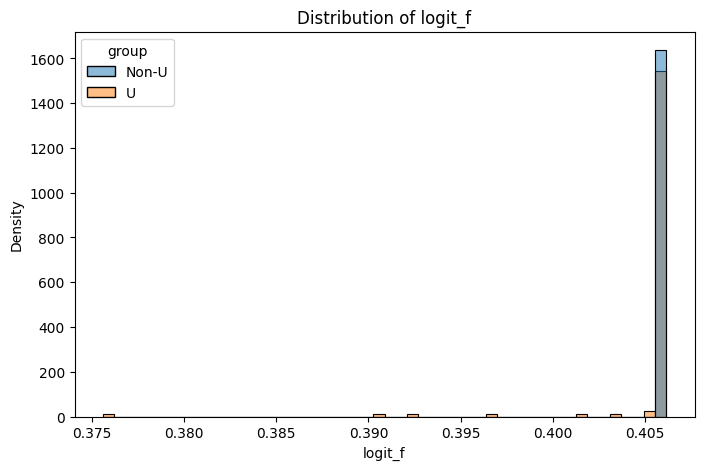

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df_fl[['REMOVAL_TYPE_CODE', 'logit_f']].dropna()
df_plot['group'] = df_plot['REMOVAL_TYPE_CODE'].apply(lambda x: 'U' if x == 'U' else 'Non-U')

plt.figure(figsize=(8,5))
sns.histplot(data=df_plot, x='logit_f', hue='group', bins=50, stat='density', common_norm=False, alpha=0.5)

plt.title('Distribution of logit_f')
plt.show()